# Dissertation Title : Evaluating Machine Learning Models for Multi-Class Cyberbullying Detection Using Natural Language Processing Techniques and Prototype Development

# Importing Libraries and Basic Few Operations 

In [6]:
# I import NumPy for performing numerical computations.
import numpy as np

# I import Pandas for loading and manipulating the dataset.
import pandas as pd

# I import Matplotlib for creating basic data visualizations.
import matplotlib.pyplot as plt

# I import Seaborn for creating statistical visualizations.
import seaborn as sns

# I load my Cyberbullying Classification dataset into a DataFrame.
df = pd.read_csv("cyberbullying_tweets.csv")

# I display the first five records to understand the structure of my dataset.
df.head()

# I check the number of rows and columns present in my dataset.
df.shape

# I view information about the dataset, including data types and missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


# Intial Data Inspection 

In [7]:
# I display the first five records of my dataset.
df.head()

# I display the last five records of my dataset.
df.tail()

# I check the shape of my dataset.
print("Dataset Shape:", df.shape)

# I display detailed information about my dataset.
df.info()

# I display the total number of observations in my dataset.
print("Number of Observations:", df.shape[0])

# I display the total number of columns in my dataset.
print("Number of Columns:", df.shape[1])

# I display the names of all columns in my dataset.
print("Column Names:")
print(df.columns.tolist())

# I display the data type of each column.
print(df.dtypes)

# I specify the target variable used in my dissertation.
target_variable = "cyberbullying_type"

# I display the target variable.
print("Target Variable:", target_variable)

# I display the unique class labels present in the target variable.
print(df["cyberbullying_type"].unique())

# I count the number of records belonging to each target class.
print(df["cyberbullying_type"].value_counts())

# I check the number of duplicate records in my dataset.
print("Duplicate Records:", df.duplicated().sum())

# I check the number of missing values in each column.
print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (47692, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB
Number of Observations: 47692
Number of Columns: 2
Column Names:
['tweet_text', 'cyberbullying_type']
tweet_text            object
cyberbullying_type    object
dtype: object
Target Variable: cyberbullying_type
['not_cyberbullying' 'gender' 'religion' 'other_cyberbullying' 'age'
 'ethnicity']
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64
Duplicate Records: 36
Missing Values:
tweet_text            0
cyberbullying_type    0
dtype: int64


# Data Processing and Text Pre-Processing 

In [ ]:
# I import the libraries required for text preprocessing.
import re
import string
import nltk

# I download the English stopwords required for text preprocessing.
nltk.download('stopwords')

# I import the English stopwords.
from nltk.corpus import stopwords

# I import the Porter Stemmer for stemming words.
from nltk.stem import PorterStemmer

In [9]:
# I check the number of missing values in my dataset.
print("Missing Values Before Preprocessing:")
print(df.isnull().sum())

# I remove all rows containing missing values.
df = df.dropna()

# I verify that all missing values have been removed.
print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())

# I check the number of duplicate records before removing them.
print("\nDuplicate Records Before Removal:", df.duplicated().sum())

# I remove duplicate records from my dataset.
df = df.drop_duplicates()

# I verify that duplicate records have been removed.
print("Duplicate Records After Removal:", df.duplicated().sum())

# I create a list of English stopwords.
stop_words = set(stopwords.words('english'))

# I create a Porter Stemmer object.
stemmer = PorterStemmer()

# I create a function to preprocess the tweet text.
def preprocess_text(text):

    # I convert all text to lowercase.
    text = text.lower()

    # I remove punctuation from the text.
    text = text.translate(str.maketrans('', '', string.punctuation))

    # I remove numbers from the text.
    text = re.sub(r'\d+', '', text)

    # I remove extra white spaces.
    text = re.sub(r'\s+', ' ', text).strip()

    # I split the sentence into individual words.
    words = text.split()

    # I remove English stopwords.
    words = [word for word in words if word not in stop_words]

    # I apply stemming to each word.
    words = [stemmer.stem(word) for word in words]

    # I join the processed words into a single sentence.
    return " ".join(words)

# I apply text preprocessing to the tweet_text column.
df["tweet_text"] = df["tweet_text"].apply(preprocess_text)

# I display the first five rows of the cleaned dataset.
print("\nFirst Five Records After Preprocessing:")
print(df.head())

# I check the final shape of my cleaned dataset.
print("\nDataset Shape After Preprocessing:", df.shape)

# I display information about my cleaned dataset.
print("\nDataset Information:")
df.info()

Missing Values Before Preprocessing:
tweet_text            0
cyberbullying_type    0
dtype: int64

Missing Values After Preprocessing:
tweet_text            0
cyberbullying_type    0
dtype: int64

Duplicate Records Before Removal: 36
Duplicate Records After Removal: 0

First Five Records After Preprocessing:
                                          tweet_text cyberbullying_type
0                 word katandandr food crapilici mkr  not_cyberbullying
1  aussietv white mkr theblock imacelebrityau tod...  not_cyberbullying
2       xochitlsuckkk classi whore red velvet cupcak  not_cyberbullying
3  jasongio meh p thank head concern anoth angri ...  not_cyberbullying
4  rudhoeenglish isi account pretend kurdish acco...  not_cyberbullying

Dataset Shape After Preprocessing: (47656, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 47656 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              -------------

# Exploratory Data Analysis 

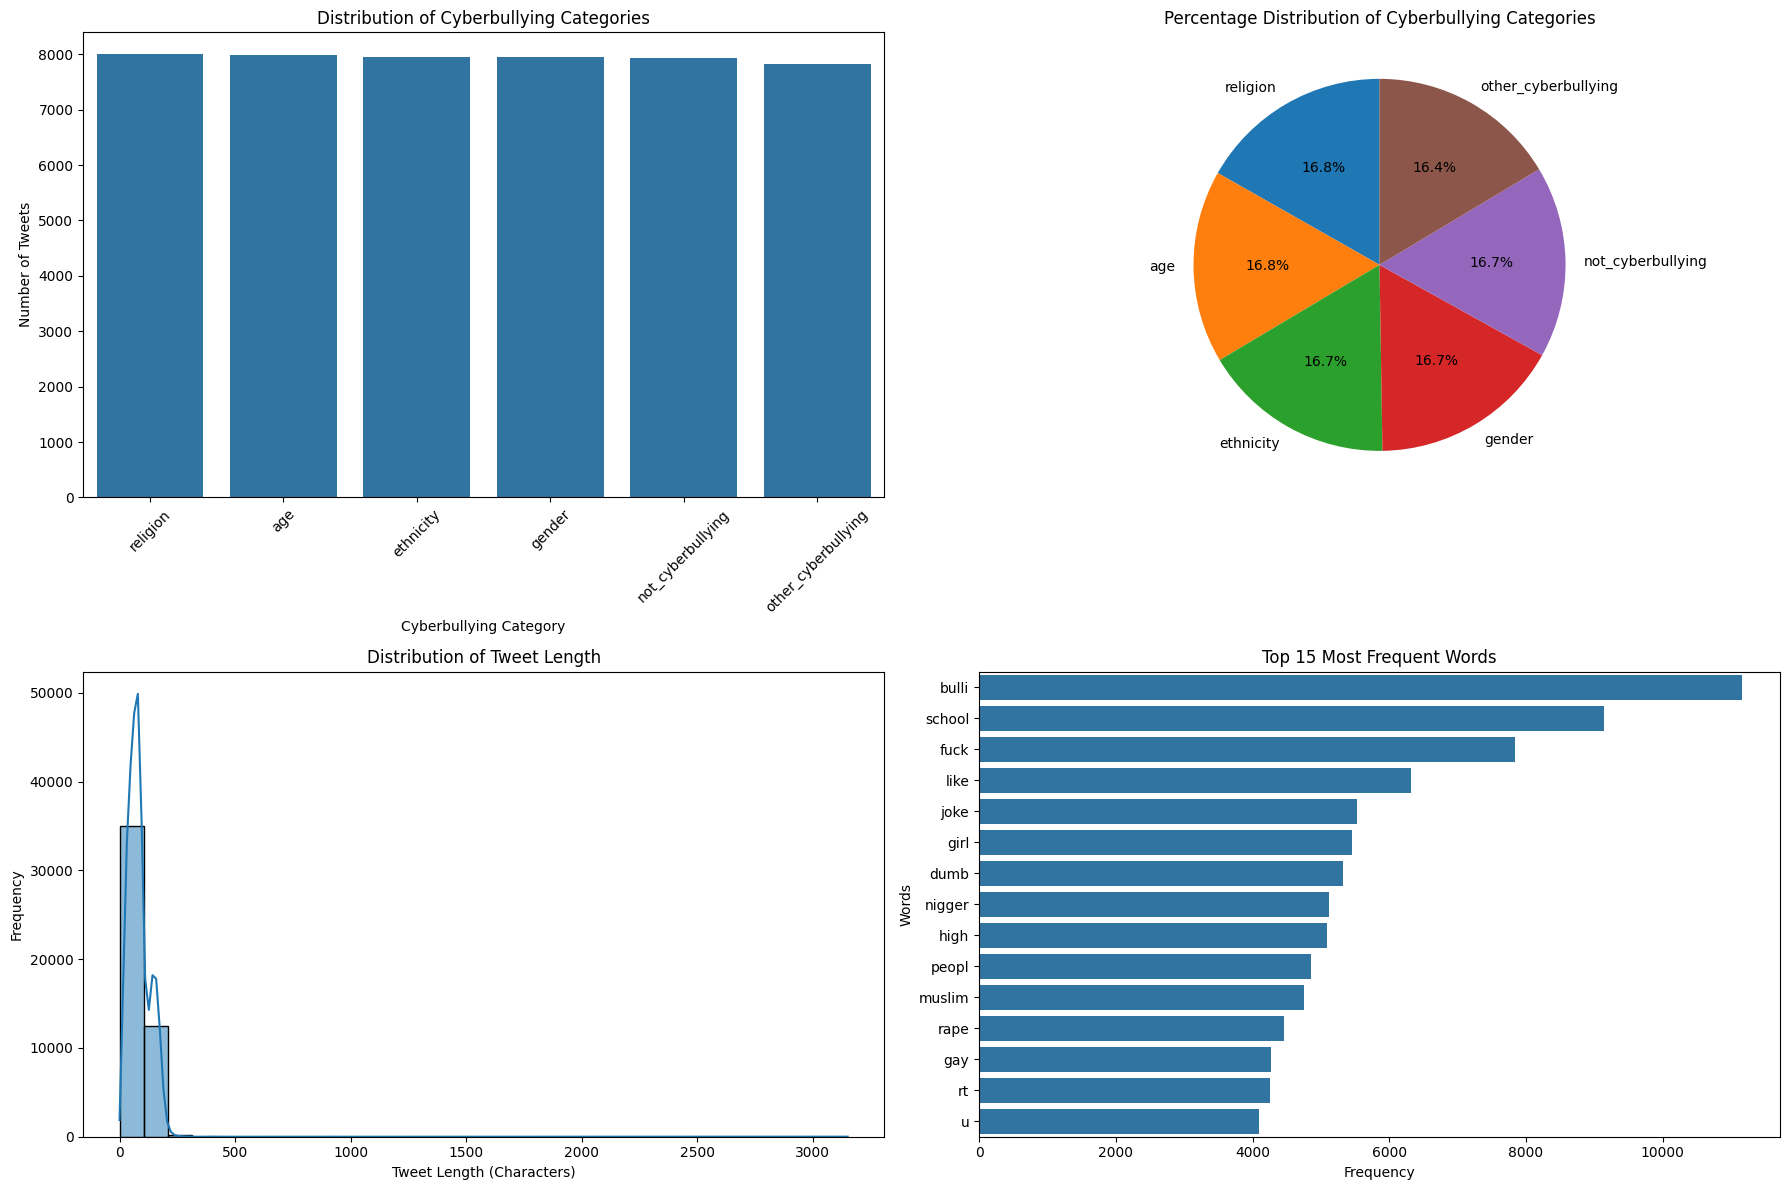

In [10]:
# I create a figure to display all EDA plots.
plt.figure(figsize=(18,12))


# Distribution of Cyberbullying Categories
# I display the distribution of the target variable.
plt.subplot(2,2,1)
sns.countplot(data=df, x='cyberbullying_type', order=df['cyberbullying_type'].value_counts().index)
plt.title("Distribution of Cyberbullying Categories")
plt.xlabel("Cyberbullying Category")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)


#  Percentage Distribution of Categories
# I display the percentage distribution of each target class.
plt.subplot(2,2,2)
df['cyberbullying_type'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Percentage Distribution of Cyberbullying Categories")
plt.ylabel("")


# Tweet Length Distribution


# I calculate the number of characters in each tweet.
df['Tweet_Length'] = df['tweet_text'].apply(len)

# I display the distribution of tweet lengths.
plt.subplot(2,2,3)
sns.histplot(df['Tweet_Length'], bins=30, kde=True)
plt.title("Distribution of Tweet Length")
plt.xlabel("Tweet Length (Characters)")
plt.ylabel("Frequency")


# Top 15 Most Frequent Words

# I combine all tweets into a single text.
all_words = " ".join(df["tweet_text"])

# I count the frequency of each word.
from collections import Counter
word_counts = Counter(all_words.split())

# I identify the 15 most frequent words.
common_words = word_counts.most_common(15)

# I convert the results into a DataFrame.
word_df = pd.DataFrame(common_words, columns=["Word","Frequency"])

# I display the most frequent words.
plt.subplot(2,2,4)
sns.barplot(data=word_df, x="Frequency", y="Word")
plt.title("Top 15 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

# I adjust the spacing between all plots.
plt.tight_layout()

# I display all EDA plots.
plt.show()

# Feature Selection and Engineering

In [11]:
# I import the libraries required for feature engineering.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# I select the input feature from my dataset.
X = df["tweet_text"]

# I select the target variable from my dataset.
y = df["cyberbullying_type"]

# I create a Label Encoder to convert class labels into numerical values.
label_encoder = LabelEncoder()

# I transform the target variable into numerical labels.
y = label_encoder.fit_transform(y)

# I create a TF-IDF Vectorizer.
tfidf = TfidfVectorizer(max_features=5000)

# I convert the textual data into numerical TF-IDF features.
X = tfidf.fit_transform(X)

# I display the shape of the TF-IDF feature matrix.
print("TF-IDF Feature Matrix Shape:", X.shape)

# I display the shape of the target variable.
print("Target Variable Shape:", y.shape)

# I display the first 20 TF-IDF feature names.
print("\nFirst 20 TF-IDF Features:")
print(tfidf.get_feature_names_out()[:20])

TF-IDF Feature Matrix Shape: (47656, 5000)
Target Variable Shape: (47656,)

First 20 TF-IDF Features:
['aa' 'aalwuhaib' 'ab' 'abandon' 'abc' 'abdul' 'abe' 'abil' 'abl'
 'ableist' 'abolish' 'abort' 'abroad' 'absolut' 'absurd' 'abt'
 'abunaseeha' 'abus' 'ac' 'academ']


# Splitting the Dataset 

In [12]:
# I import the library required for splitting the dataset.
from sklearn.model_selection import train_test_split

# I split the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# I display the shape of the training feature set.
print("Training Feature Shape:", X_train.shape)

# I display the shape of the testing feature set.
print("Testing Feature Shape:", X_test.shape)

# I display the shape of the training target variable.
print("Training Target Shape:", y_train.shape)

# I display the shape of the testing target variable.
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (38124, 5000)
Testing Feature Shape: (9532, 5000)
Training Target Shape: (38124,)
Testing Target Shape: (9532,)


# Model Selection and Training 

# Default Models 

# Model 1 : Logistic Regression

In [13]:
# I import the required libraries.
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I create the Logistic Regression classifier.
logistic_regression_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

# I train the Logistic Regression model using the training dataset.
logistic_regression_model.fit(
    X_train,
    y_train
)

# I predict the class labels for the testing dataset.
y_pred_lr = logistic_regression_model.predict(
    X_test
)

# I predict the class probabilities for the testing dataset.
y_prob_lr = logistic_regression_model.predict_proba(
    X_test
)

# I calculate the Accuracy.
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

# I calculate the Precision.
lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

# I calculate the Recall.
lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

# I calculate the F1-score.
lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

# I calculate the weighted ROC-AUC score.
lr_roc_auc = roc_auc_score(
    y_test,
    y_prob_lr,
    multi_class="ovr",
    average="weighted"
)

# I display the evaluation results.
print("Logistic Regression Performance")

print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_roc_auc, 4))

# I display the detailed classification report.
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_
    )
)

Logistic Regression Performance
Accuracy : 0.8331
Precision: 0.8376
Recall   : 0.8331
F1-score : 0.8346
ROC-AUC  : 0.9689

Classification Report
                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      1598
          ethnicity       0.98      0.97      0.97      1592
             gender       0.92      0.84      0.87      1590
  not_cyberbullying       0.60      0.58      0.59      1587
other_cyberbullying       0.61      0.69      0.65      1565
           religion       0.96      0.95      0.95      1600

           accuracy                           0.83      9532
          macro avg       0.84      0.83      0.83      9532
       weighted avg       0.84      0.83      0.83      9532



# Model 2 : Multinominal Naive Bayes 

In [14]:
# I import the required libraries.
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I create the Naïve Bayes classifier.
naive_bayes_model = MultinomialNB()

# I train the Naïve Bayes model using the training dataset.
naive_bayes_model.fit(
    X_train,
    y_train
)

# I predict the class labels for the testing dataset.
y_pred_nb = naive_bayes_model.predict(
    X_test
)

# I predict the class probabilities for the testing dataset.
y_prob_nb = naive_bayes_model.predict_proba(
    X_test
)

# I calculate the Accuracy.
nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

# I calculate the Precision.
nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

# I calculate the Recall.
nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

# I calculate the F1-score.
nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

# I calculate the weighted ROC-AUC score.
nb_roc_auc = roc_auc_score(
    y_test,
    y_prob_nb,
    multi_class="ovr",
    average="weighted"
)

# I display the evaluation results.
print("Naïve Bayes Performance")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-score :", round(nb_f1, 4))
print("ROC-AUC  :", round(nb_roc_auc, 4))

# I display the detailed classification report.
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=label_encoder.classes_
    )
)

Naïve Bayes Performance
Accuracy : 0.7766
Precision: 0.7661
Recall   : 0.7766
F1-score : 0.7634
ROC-AUC  : 0.958

Classification Report
                     precision    recall  f1-score   support

                age       0.79      0.97      0.87      1598
          ethnicity       0.86      0.91      0.89      1592
             gender       0.84      0.81      0.83      1590
  not_cyberbullying       0.66      0.41      0.51      1587
other_cyberbullying       0.63      0.58      0.61      1565
           religion       0.80      0.96      0.87      1600

           accuracy                           0.78      9532
          macro avg       0.77      0.78      0.76      9532
       weighted avg       0.77      0.78      0.76      9532



# Model 3 : XGBoost 

In [15]:
# I import the required libraries.
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I create the XGBoost classifier.
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

# I train the XGBoost model using the training dataset.
xgb_model.fit(
    X_train,
    y_train
)

# I predict the class labels for the testing dataset.
y_pred_xgb = xgb_model.predict(
    X_test
)

# I predict the class probabilities for the testing dataset.
y_prob_xgb = xgb_model.predict_proba(
    X_test
)

# I calculate the Accuracy.
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

# I calculate the Precision.
xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

# I calculate the Recall.
xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

# I calculate the F1-score.
xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

# I calculate the weighted ROC-AUC score.
xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb,
    multi_class="ovr",
    average="weighted"
)

# I display the evaluation results.
print("XGBoost Performance")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1-score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))

# I display the detailed classification report.
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=label_encoder.classes_
    )
)

XGBoost Performance
Accuracy : 0.8312
Precision: 0.8504
Recall   : 0.8312
F1-score : 0.8295
ROC-AUC  : 0.9702

Classification Report
                     precision    recall  f1-score   support

                age       0.98      0.97      0.97      1598
          ethnicity       0.99      0.97      0.98      1592
             gender       0.92      0.82      0.87      1590
  not_cyberbullying       0.68      0.42      0.52      1587
other_cyberbullying       0.55      0.87      0.68      1565
           religion       0.97      0.94      0.96      1600

           accuracy                           0.83      9532
          macro avg       0.85      0.83      0.83      9532
       weighted avg       0.85      0.83      0.83      9532



# Model 4 : Random Forest 

In [10]:
# I import the required libraries.
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I create the Random Forest classifier.
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# I train the Random Forest model using the training dataset.
random_forest_model.fit(
    X_train,
    y_train
)

# I predict the class labels for the testing dataset.
y_pred_rf = random_forest_model.predict(
    X_test
)

# I predict the class probabilities for the testing dataset.
y_prob_rf = random_forest_model.predict_proba(
    X_test
)

# I calculate the Accuracy.
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

# I calculate the Precision.
rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

# I calculate the Recall.
rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

# I calculate the F1-score.
rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

# I calculate the weighted ROC-AUC score.
rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class="ovr",
    average="weighted"
)

# I display the evaluation results.
print("Random Forest Performance")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

# I display the detailed classification report.
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

Random Forest Performance
Accuracy : 0.8227
Precision: 0.8268
Recall   : 0.8227
F1-score : 0.8235
ROC-AUC  : 0.9615

Classification Report
                     precision    recall  f1-score   support

                age       0.97      0.98      0.97      1598
          ethnicity       0.98      0.98      0.98      1592
             gender       0.91      0.84      0.87      1590
  not_cyberbullying       0.57      0.51      0.54      1587
other_cyberbullying       0.56      0.66      0.60      1565
           religion       0.96      0.97      0.97      1600

           accuracy                           0.82      9532
          macro avg       0.83      0.82      0.82      9532
       weighted avg       0.83      0.82      0.82      9532



# Combined Comparative Table for all Default Models

In [11]:
# I import the required library.
import pandas as pd

# I create a dataframe containing the performance of all models.
df_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        nb_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        nb_recall,
        rf_recall,
        xgb_recall
    ],
    "F1-score": [
        lr_f1,
        nb_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        nb_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

# I round all evaluation metrics to four decimal places.
df_results.iloc[:, 1:] = df_results.iloc[:, 1:].round(4)

# I sort the models based on the F1-score.
df_results = df_results.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

# I display the comparative results.
print()
print("Comparative Performance of Machine Learning Models")
print()

display(
    df_results.style
    .hide(axis="index")
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
    .set_caption("Comparative Performance of Machine Learning Models")
)


Comparative Performance of Machine Learning Models



Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.8331,0.8376,0.8331,0.8346,0.9689
XGBoost,0.8312,0.8504,0.8312,0.8295,0.9702
Random Forest,0.8227,0.8268,0.8227,0.8235,0.9615
Naive Bayes,0.7766,0.7661,0.7766,0.7634,0.9580


# Visual Analysis 

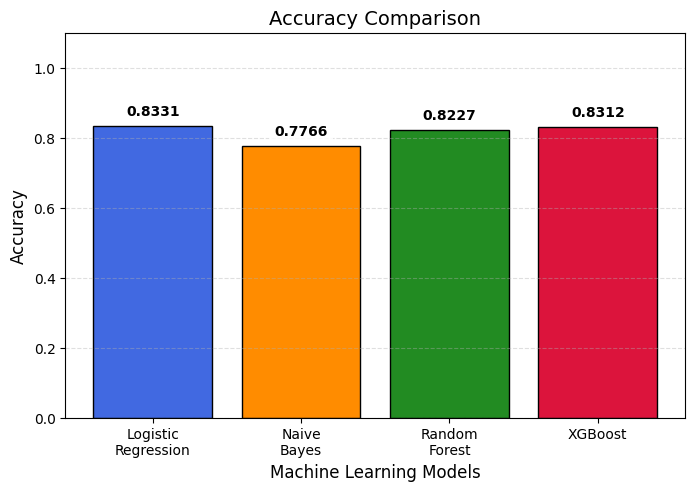

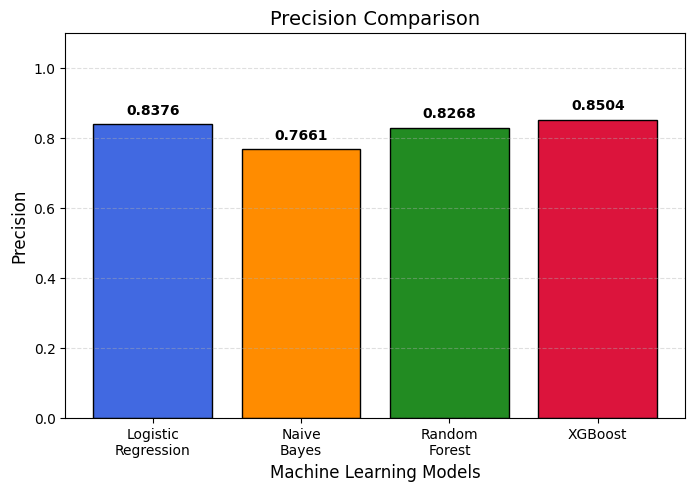

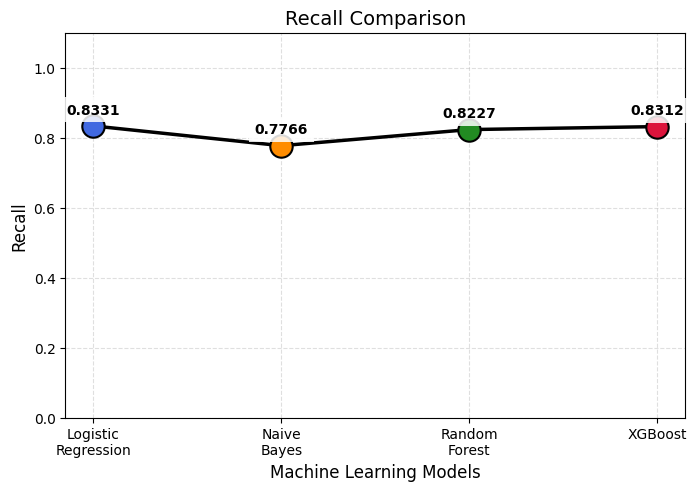

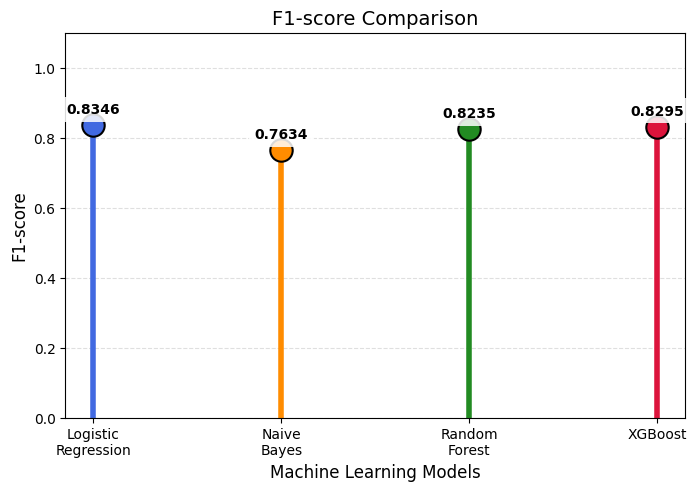

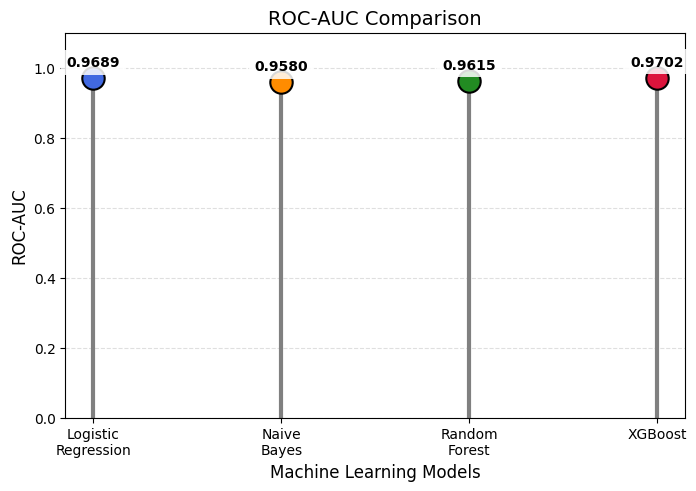

In [12]:
# I import the required libraries.
import matplotlib.pyplot as plt

# I store the model names.
models = [
    "Logistic\nRegression",
    "Naive\nBayes",
    "Random\nForest",
    "XGBoost"
]

# I store the evaluation metrics.
accuracy = [
    lr_accuracy,
    nb_accuracy,
    rf_accuracy,
    xgb_accuracy
]

precision = [
    lr_precision,
    nb_precision,
    rf_precision,
    xgb_precision
]

recall = [
    lr_recall,
    nb_recall,
    rf_recall,
    xgb_recall
]

f1_scores = [
    lr_f1,
    nb_f1,
    rf_f1,
    xgb_f1
]

roc_auc = [
    lr_roc_auc,
    nb_roc_auc,
    rf_roc_auc,
    xgb_roc_auc
]

# I define the colours for each model.
colors = [
    "royalblue",
    "darkorange",
    "forestgreen",
    "crimson"
]

# I create the Accuracy Bar Chart.

plt.figure(figsize=(8,5))

plt.bar(
    models,
    accuracy,
    color=colors,
    edgecolor="black"
)

plt.title("Accuracy Comparison", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0,1.10)

for i, value in enumerate(accuracy):

    plt.text(
        i,
        value+0.03,
        f"{value:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# I create the Precision Bar Chart.

plt.figure(figsize=(8,5))

plt.bar(
    models,
    precision,
    color=colors,
    edgecolor="black"
)

plt.title("Precision Comparison", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.ylim(0,1.10)

for i, value in enumerate(precision):

    plt.text(
        i,
        value+0.03,
        f"{value:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# I create the Recall Line Chart.

plt.figure(figsize=(8,5))

plt.plot(
    models,
    recall,
    linewidth=2.5,
    color="black"
)

for i, value in enumerate(recall):

    plt.scatter(
        models[i],
        value,
        s=260,
        color=colors[i],
        edgecolor="black",
        linewidth=1.5,
        zorder=3
    )

    plt.text(
        i,
        value+0.035,
        f"{value:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

plt.title("Recall Comparison", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Recall", fontsize=12)
plt.ylim(0,1.10)

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

# I create the F1-score Lollipop Plot.

plt.figure(figsize=(8,5))

for i, value in enumerate(f1_scores):

    plt.vlines(
        x=i,
        ymin=0,
        ymax=value,
        color=colors[i],
        linewidth=4
    )

    plt.scatter(
        i,
        value,
        s=260,
        color=colors[i],
        edgecolor="black",
        linewidth=1.5,
        zorder=3
    )

    plt.text(
        i,
        value+0.035,
        f"{value:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

plt.xticks(range(len(models)), models)

plt.title("F1-score Comparison", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("F1-score", fontsize=12)
plt.ylim(0,1.10)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# I create the ROC-AUC Stem Plot.

plt.figure(figsize=(8,5))

markerline, stemlines, baseline = plt.stem(
    range(len(models)),
    roc_auc
)

plt.setp(
    markerline,
    visible=False
)

plt.setp(
    stemlines,
    color="gray",
    linewidth=3
)

plt.setp(
    baseline,
    visible=False
)

for i, value in enumerate(roc_auc):

    plt.scatter(
        i,
        value,
        s=260,
        color=colors[i],
        edgecolor="black",
        linewidth=1.5,
        zorder=3
    )

    plt.text(
        i,
        value+0.035,
        f"{value:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

plt.xticks(range(len(models)), models)

plt.title("ROC-AUC Comparison", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("ROC-AUC", fontsize=12)
plt.ylim(0,1.10)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# Combined Grouped Bar Chart for all Default Models 

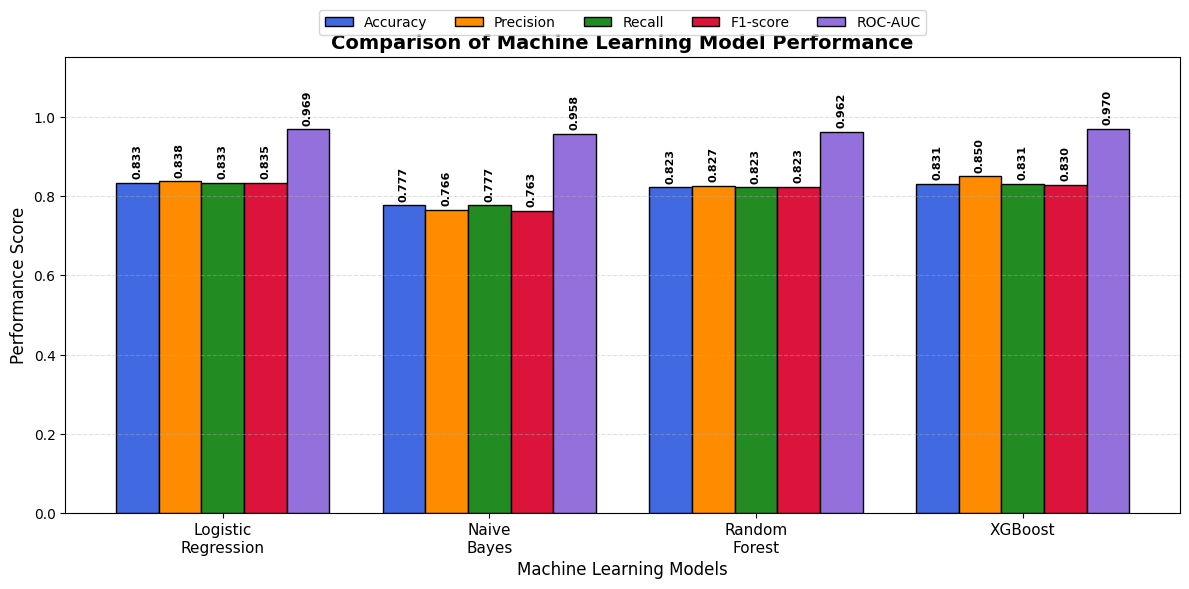

In [13]:
# I import the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I store the model names.
models = [
    "Logistic\nRegression",
    "Naive\nBayes",
    "Random\nForest",
    "XGBoost"
]

# I store all evaluation metrics.
accuracy = [lr_accuracy, nb_accuracy, rf_accuracy, xgb_accuracy]
precision = [lr_precision, nb_precision, rf_precision, xgb_precision]
recall = [lr_recall, nb_recall, rf_recall, xgb_recall]
f1_scores = [lr_f1, nb_f1, rf_f1, xgb_f1]
roc_auc = [lr_roc_auc, nb_roc_auc, rf_roc_auc, xgb_roc_auc]

# I create the x-axis positions.
x = np.arange(len(models))

# I define the width of each bar.
width = 0.16

# I create the grouped bar chart.
plt.figure(figsize=(12,6))

bars1 = plt.bar(
    x - 2*width,
    accuracy,
    width,
    label="Accuracy",
    color="royalblue",
    edgecolor="black"
)

bars2 = plt.bar(
    x - width,
    precision,
    width,
    label="Precision",
    color="darkorange",
    edgecolor="black"
)

bars3 = plt.bar(
    x,
    recall,
    width,
    label="Recall",
    color="forestgreen",
    edgecolor="black"
)

bars4 = plt.bar(
    x + width,
    f1_scores,
    width,
    label="F1-score",
    color="crimson",
    edgecolor="black"
)

bars5 = plt.bar(
    x + 2*width,
    roc_auc,
    width,
    label="ROC-AUC",
    color="mediumpurple",
    edgecolor="black"
)

# I add value labels above each bar.
for bars in [bars1, bars2, bars3, bars4, bars5]:

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=8,
            fontweight="bold"
        )

# I customize the chart.
plt.xticks(
    x,
    models,
    fontsize=11
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=12
)

plt.ylabel(
    "Performance Score",
    fontsize=12
)

plt.title(
    "Comparison of Machine Learning Model Performance",
    fontsize=14,
    fontweight="bold"
)

plt.ylim(0, 1.15)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=5,
    fontsize=10
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

# Combined AUC-ROC Curve for all Default Models 

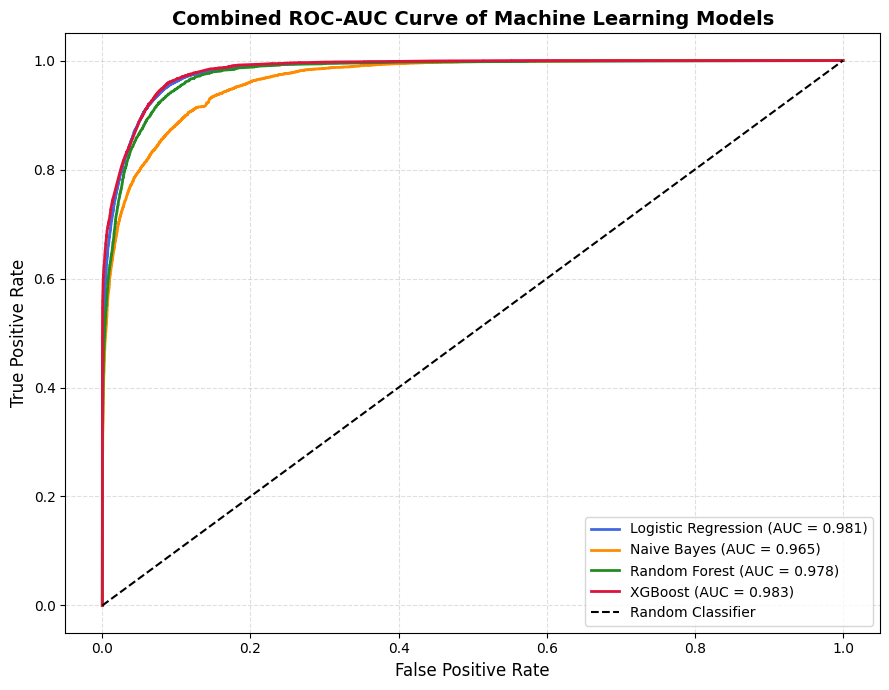

In [14]:
# I import the required libraries.
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# I convert the true labels into binary format.
y_test_bin = label_binarize(
    y_test,
    classes=range(len(label_encoder.classes_))
)

# I calculate the micro-average ROC curve for Logistic Regression.
fpr_lr, tpr_lr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_lr.ravel()
)

roc_auc_lr = auc(
    fpr_lr,
    tpr_lr
)

# I calculate the micro-average ROC curve for Naive Bayes.
fpr_nb, tpr_nb, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_nb.ravel()
)

roc_auc_nb = auc(
    fpr_nb,
    tpr_nb
)

# I calculate the micro-average ROC curve for Random Forest.
fpr_rf, tpr_rf, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_rf.ravel()
)

roc_auc_rf = auc(
    fpr_rf,
    tpr_rf
)

# I calculate the micro-average ROC curve for XGBoost.
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_xgb.ravel()
)

roc_auc_xgb = auc(
    fpr_xgb,
    tpr_xgb
)

# I create the combined ROC-AUC curve.
plt.figure(figsize=(9,7))

plt.plot(
    fpr_lr,
    tpr_lr,
    color="royalblue",
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

plt.plot(
    fpr_nb,
    tpr_nb,
    color="darkorange",
    linewidth=2,
    label=f"Naive Bayes (AUC = {roc_auc_nb:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    color="forestgreen",
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    color="crimson",
    linewidth=2,
    label=f"XGBoost (AUC = {roc_auc_xgb:.3f})"
)

# I plot the random classifier line.
plt.plot(
    [0,1],
    [0,1],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title(
    "Combined ROC-AUC Curve of Machine Learning Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

# Hyper Parameter Tuning 

# Model 1 : Logistic Regression 

In [15]:
# I import the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I define the hyperparameter grid.
param_grid_lr = {
    "C": [0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

# I create the Logistic Regression model.
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# I perform Grid Search Cross Validation.
grid_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I train the Grid Search model.
grid_lr.fit(
    X_train,
    y_train
)

# I obtain the best Logistic Regression model.
best_lr_model = grid_lr.best_estimator_

# I display the best hyperparameters.
print("Best Hyperparameters")
print(grid_lr.best_params_)

# I display the best cross-validation score.
print("\nBest Cross Validation Accuracy:",
      round(grid_lr.best_score_,4))

# I predict the class labels.
y_pred_grid_lr = best_lr_model.predict(
    X_test
)

# I predict the class probabilities.
y_prob_grid_lr = best_lr_model.predict_proba(
    X_test
)

# I calculate the Accuracy.
grid_lr_accuracy = accuracy_score(
    y_test,
    y_pred_grid_lr
)

# I calculate the Precision.
grid_lr_precision = precision_score(
    y_test,
    y_pred_grid_lr,
    average="weighted"
)

# I calculate the Recall.
grid_lr_recall = recall_score(
    y_test,
    y_pred_grid_lr,
    average="weighted"
)

# I calculate the F1-score.
grid_lr_f1 = f1_score(
    y_test,
    y_pred_grid_lr,
    average="weighted"
)

# I calculate the ROC-AUC score.
grid_lr_roc_auc = roc_auc_score(
    y_test,
    y_prob_grid_lr,
    multi_class="ovr",
    average="weighted"
)

# I display the evaluation metrics.
print("\nLogistic Regression After Hyperparameter Tuning")


print("Accuracy :", round(grid_lr_accuracy,4))
print("Precision:", round(grid_lr_precision,4))
print("Recall   :", round(grid_lr_recall,4))
print("F1-score :", round(grid_lr_f1,4))
print("ROC-AUC  :", round(grid_lr_roc_auc,4))

# I display the classification report.
print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_grid_lr,
        target_names=label_encoder.classes_
    )
)

Best Hyperparameters
{'C': 1, 'solver': 'liblinear'}

Best Cross Validation Accuracy: 0.8291

Logistic Regression After Hyperparameter Tuning
Accuracy : 0.8331
Precision: 0.835
Recall   : 0.8331
F1-score : 0.833
ROC-AUC  : 0.9695

Classification Report
                     precision    recall  f1-score   support

                age       0.93      0.98      0.95      1598
          ethnicity       0.97      0.97      0.97      1592
             gender       0.91      0.83      0.87      1590
  not_cyberbullying       0.62      0.56      0.59      1587
other_cyberbullying       0.62      0.70      0.66      1565
           religion       0.96      0.95      0.95      1600

           accuracy                           0.83      9532
          macro avg       0.83      0.83      0.83      9532
       weighted avg       0.84      0.83      0.83      9532



# Model 2 :Multinominal Naive Bayes

In [16]:
# I import the required libraries.
from sklearn.naive_bayes import MultinomialNB

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I define the hyperparameter grid.
param_grid_nb = {

    "alpha": [0.1, 0.5, 1.0]

}

# I create the Multinomial Naive Bayes model.
nb_model = MultinomialNB()

# I perform Grid Search Cross Validation.
grid_nb = GridSearchCV(
    estimator=nb_model,
    param_grid=param_grid_nb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I train the Grid Search model.
grid_nb.fit(
    X_train,
    y_train
)

# I obtain the best Naive Bayes model.
best_nb_model = grid_nb.best_estimator_

# I display the best hyperparameters.
print("Best Hyperparameters")
print(grid_nb.best_params_)

# I display the best cross-validation score.
print("\nBest Cross Validation Accuracy:",
      round(grid_nb.best_score_,4))

# I predict the class labels.
y_pred_grid_nb = best_nb_model.predict(
    X_test
)

# I predict the class probabilities.
y_prob_grid_nb = best_nb_model.predict_proba(
    X_test
)

# I calculate the Accuracy.
grid_nb_accuracy = accuracy_score(
    y_test,
    y_pred_grid_nb
)

# I calculate the Precision.
grid_nb_precision = precision_score(
    y_test,
    y_pred_grid_nb,
    average="weighted"
)

# I calculate the Recall.
grid_nb_recall = recall_score(
    y_test,
    y_pred_grid_nb,
    average="weighted"
)

# I calculate the F1-score.
grid_nb_f1 = f1_score(
    y_test,
    y_pred_grid_nb,
    average="weighted"
)

# I calculate the ROC-AUC score.
grid_nb_roc_auc = roc_auc_score(
    y_test,
    y_prob_grid_nb,
    multi_class="ovr",
    average="weighted"
)

# I display the evaluation metrics.
print("\nNaive Bayes After Hyperparameter Tuning")


print("Accuracy :", round(grid_nb_accuracy,4))
print("Precision:", round(grid_nb_precision,4))
print("Recall   :", round(grid_nb_recall,4))
print("F1-score :", round(grid_nb_f1,4))
print("ROC-AUC  :", round(grid_nb_roc_auc,4))

# I display the classification report.
print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_grid_nb,
        target_names=label_encoder.classes_
    )
)

Best Hyperparameters
{'alpha': 1.0}

Best Cross Validation Accuracy: 0.7732

Naive Bayes After Hyperparameter Tuning
Accuracy : 0.7766
Precision: 0.7661
Recall   : 0.7766
F1-score : 0.7634
ROC-AUC  : 0.958

Classification Report
                     precision    recall  f1-score   support

                age       0.79      0.97      0.87      1598
          ethnicity       0.86      0.91      0.89      1592
             gender       0.84      0.81      0.83      1590
  not_cyberbullying       0.66      0.41      0.51      1587
other_cyberbullying       0.63      0.58      0.61      1565
           religion       0.80      0.96      0.87      1600

           accuracy                           0.78      9532
          macro avg       0.77      0.78      0.76      9532
       weighted avg       0.77      0.78      0.76      9532



# Model 3 : XGBoost 

In [16]:
# I import the required libraries.
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I define the hyperparameter search space.
param_dist_xgb = {

    "n_estimators": [100, 150],

    "max_depth": [3, 5],

    "learning_rate": [0.1, 0.2]

}

# I create the XGBoost model.
xgb_model = XGBClassifier(

    random_state=42,

    eval_metric="mlogloss"

)

# I perform Randomized Search Cross Validation.
random_xgb = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_dist_xgb,

    n_iter=4,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1

)

# I train the Randomized Search model.
random_xgb.fit(

    X_train,

    y_train

)

# I obtain the best XGBoost model.
best_xgb_model = random_xgb.best_estimator_

# I display the best hyperparameters.
print("Best Hyperparameters")
print(random_xgb.best_params_)

# I display the best cross-validation score.
print(
    "\nBest Cross Validation Accuracy:",
    round(random_xgb.best_score_, 4)
)

# I predict the class labels.
y_pred_random_xgb = best_xgb_model.predict(
    X_test
)

# I predict the class probabilities.
y_prob_random_xgb = best_xgb_model.predict_proba(
    X_test
)

# I calculate the Accuracy.
random_xgb_accuracy = accuracy_score(

    y_test,

    y_pred_random_xgb

)

# I calculate the Precision.
random_xgb_precision = precision_score(

    y_test,

    y_pred_random_xgb,

    average="weighted"

)

# I calculate the Recall.
random_xgb_recall = recall_score(

    y_test,

    y_pred_random_xgb,

    average="weighted"

)

# I calculate the F1-score.
random_xgb_f1 = f1_score(

    y_test,

    y_pred_random_xgb,

    average="weighted"

)

# I calculate the ROC-AUC score.
random_xgb_roc_auc = roc_auc_score(

    y_test,

    y_prob_random_xgb,

    multi_class="ovr",

    average="weighted"

)

# I display the evaluation metrics.
print("\nXGBoost After Hyperparameter Tuning")

print("Accuracy :", round(random_xgb_accuracy, 4))
print("Precision:", round(random_xgb_precision, 4))
print("Recall   :", round(random_xgb_recall, 4))
print("F1-score :", round(random_xgb_f1, 4))
print("ROC-AUC  :", round(random_xgb_roc_auc, 4))

# I display the classification report.
print("\nClassification Report")

print(

    classification_report(

        y_test,

        y_pred_random_xgb,

        target_names=label_encoder.classes_

    )

)

Best Hyperparameters
{'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.2}

Best Cross Validation Accuracy: 0.8359

XGBoost After Hyperparameter Tuning
Accuracy : 0.8371
Precision: 0.8493
Recall   : 0.8371
F1-score : 0.836
ROC-AUC  : 0.9718

Classification Report
                     precision    recall  f1-score   support

                age       0.98      0.97      0.98      1598
          ethnicity       0.99      0.98      0.98      1592
             gender       0.92      0.84      0.87      1590
  not_cyberbullying       0.66      0.46      0.54      1587
other_cyberbullying       0.57      0.83      0.68      1565
           religion       0.97      0.95      0.96      1600

           accuracy                           0.84      9532
          macro avg       0.85      0.84      0.84      9532
       weighted avg       0.85      0.84      0.84      9532



# Model 4  : Random Forest 

In [18]:
# I import the required libraries.
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I define a small hyperparameter search space.
param_dist_rf = {

    "n_estimators": [50, 100],

    "max_depth": [10, None],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]

}

# I create the Random Forest model.
rf_model = RandomForestClassifier(

    random_state=42,

    n_jobs=-1

)

# I perform Randomized Search Cross Validation.
random_rf = RandomizedSearchCV(

    estimator=rf_model,

    param_distributions=param_dist_rf,

    n_iter=3,

    cv=3,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1

)

# I train the Random Forest model.
random_rf.fit(

    X_train,

    y_train

)

# I obtain the best Random Forest model.
best_rf_model = random_rf.best_estimator_

# I display the best hyperparameters.
print("Best Hyperparameters")
print(random_rf.best_params_)

# I display the best cross-validation score.
print(
    "\nBest Cross Validation Accuracy:",
    round(random_rf.best_score_, 4)
)

# I predict the class labels.
y_pred_random_rf = best_rf_model.predict(
    X_test
)

# I predict the class probabilities.
y_prob_random_rf = best_rf_model.predict_proba(
    X_test
)

# I calculate the Accuracy.
random_rf_accuracy = accuracy_score(

    y_test,

    y_pred_random_rf

)

# I calculate the Precision.
random_rf_precision = precision_score(

    y_test,

    y_pred_random_rf,

    average="weighted"

)

# I calculate the Recall.
random_rf_recall = recall_score(

    y_test,

    y_pred_random_rf,

    average="weighted"

)

# I calculate the F1-score.
random_rf_f1 = f1_score(

    y_test,

    y_pred_random_rf,

    average="weighted"

)

# I calculate the ROC-AUC score.
random_rf_roc_auc = roc_auc_score(

    y_test,

    y_prob_random_rf,

    multi_class="ovr",

    average="weighted"

)

# I display the evaluation metrics.
print("\nRandom Forest After Hyperparameter Tuning")

print("Accuracy :", round(random_rf_accuracy, 4))
print("Precision:", round(random_rf_precision, 4))
print("Recall   :", round(random_rf_recall, 4))
print("F1-score :", round(random_rf_f1, 4))
print("ROC-AUC  :", round(random_rf_roc_auc, 4))

# I display the classification report.
print("\nClassification Report")

print(

    classification_report(

        y_test,

        y_pred_random_rf,

        target_names=label_encoder.classes_

    )

)

Best Hyperparameters
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}

Best Cross Validation Accuracy: 0.7789

Random Forest After Hyperparameter Tuning
Accuracy : 0.7932
Precision: 0.8069
Recall   : 0.7932
F1-score : 0.788
ROC-AUC  : 0.957

Classification Report
                     precision    recall  f1-score   support

                age       0.90      0.99      0.94      1598
          ethnicity       0.96      0.96      0.96      1592
             gender       0.92      0.73      0.82      1590
  not_cyberbullying       0.63      0.37      0.47      1587
other_cyberbullying       0.51      0.76      0.61      1565
           religion       0.92      0.95      0.93      1600

           accuracy                           0.79      9532
          macro avg       0.81      0.79      0.79      9532
       weighted avg       0.81      0.79      0.79      9532



# Combined Comparative Table for All Tuned Models 

In [35]:
# I import the required libraries.
import pandas as pd
from IPython.display import display

# I create the comparison table.
df_tuned_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        grid_lr_accuracy,
        grid_nb_accuracy,
        random_rf_accuracy,
        random_xgb_accuracy
    ],

    "Precision": [
        grid_lr_precision,
        grid_nb_precision,
        random_rf_precision,
        random_xgb_precision
    ],

    "Recall": [
        grid_lr_recall,
        grid_nb_recall,
        random_rf_recall,
        random_xgb_recall
    ],

    "F1-score": [
        grid_lr_f1,
        grid_nb_f1,
        random_rf_f1,
        random_xgb_f1
    ],

    "ROC-AUC": [
        grid_lr_roc_auc,
        grid_nb_roc_auc,
        random_rf_roc_auc,
        random_xgb_roc_auc
    ]

})

# I round all evaluation metrics to four decimal places.
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

df_tuned_results[metric_columns] = df_tuned_results[
    metric_columns
].round(4)

# I display the comparison table.
display(
    df_tuned_results.style
    .set_caption(" Comparative Performance of Tuned Machine Learning Models")
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt",
        "padding": "8px"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "15pt"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-size", "12pt"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])
)

# I print the comparison table.
print("\nComparative Performance of Tuned Machine Learning Models\n")

print(df_tuned_results)

Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.833100,0.835000,0.833100,0.833000,0.969500
Naive Bayes,0.776600,0.766100,0.776600,0.763400,0.958000
Random Forest,0.793200,0.806900,0.793200,0.788000,0.957000
XGBoost,0.837100,0.849300,0.837100,0.836000,0.971800



Comparative Performance of Tuned Machine Learning Models

                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression    0.8331     0.8350  0.8331    0.8330   0.9695
1          Naive Bayes    0.7766     0.7661  0.7766    0.7634   0.9580
2        Random Forest    0.7932     0.8069  0.7932    0.7880   0.9570
3              XGBoost    0.8371     0.8493  0.8371    0.8360   0.9718


# Combined Bar Graph 

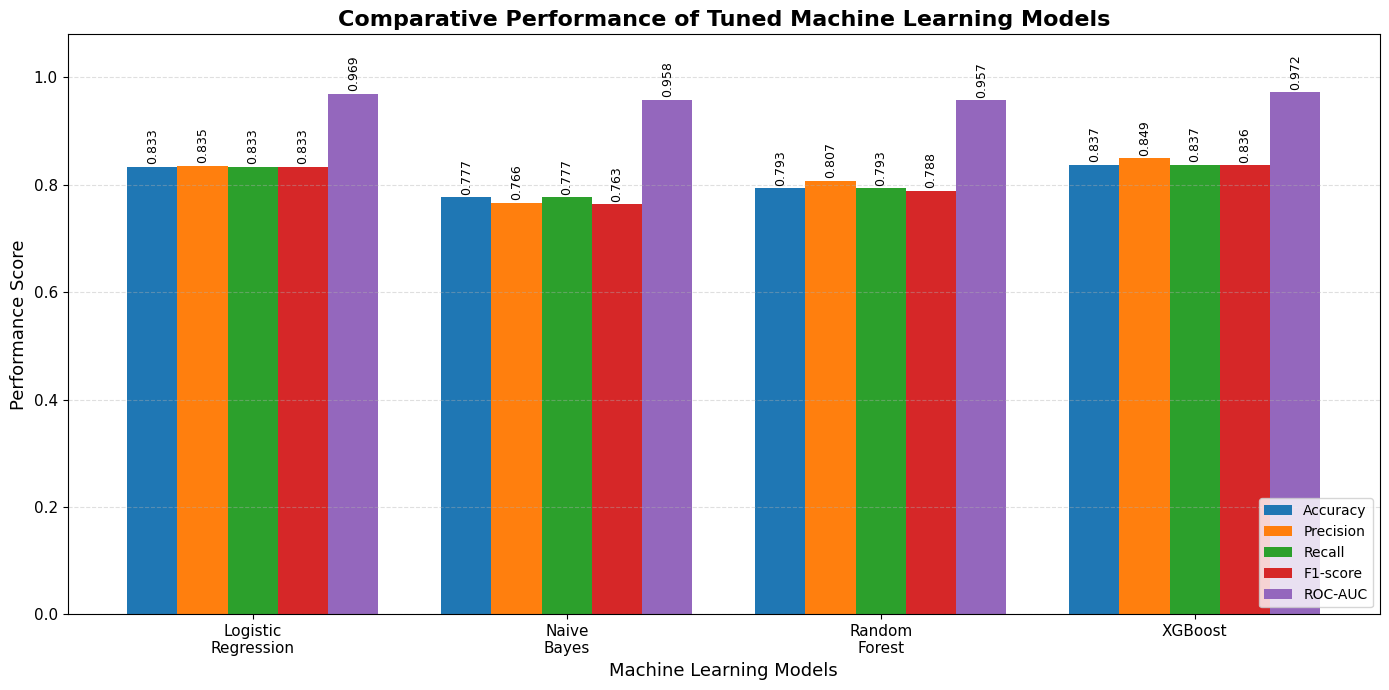

In [20]:
# I import the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I define the model names.
models = [
    "Logistic\nRegression",
    "Naive\nBayes",
    "Random\nForest",
    "XGBoost"
]

# I store the evaluation metrics.
accuracy = [
    grid_lr_accuracy,
    grid_nb_accuracy,
    random_rf_accuracy,
    random_xgb_accuracy
]

precision = [
    grid_lr_precision,
    grid_nb_precision,
    random_rf_precision,
    random_xgb_precision
]

recall = [
    grid_lr_recall,
    grid_nb_recall,
    random_rf_recall,
    random_xgb_recall
]

f1 = [
    grid_lr_f1,
    grid_nb_f1,
    random_rf_f1,
    random_xgb_f1
]

roc_auc = [
    grid_lr_roc_auc,
    grid_nb_roc_auc,
    random_rf_roc_auc,
    random_xgb_roc_auc
]

# I create the grouped bar chart.
x = np.arange(len(models))
width = 0.16

plt.figure(figsize=(14,7))

bars1 = plt.bar(x - 2*width, accuracy, width, label="Accuracy")
bars2 = plt.bar(x - width, precision, width, label="Precision")
bars3 = plt.bar(x, recall, width, label="Recall")
bars4 = plt.bar(x + width, f1, width, label="F1-score")
bars5 = plt.bar(x + 2*width, roc_auc, width, label="ROC-AUC")

# I display the values on each bar.
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=90
        )

# I customize the graph.
plt.title(
    "Comparative Performance of Tuned Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=13
)

plt.ylabel(
    "Performance Score",
    fontsize=13
)

plt.xticks(x, models, fontsize=11)

plt.yticks(fontsize=11)

plt.ylim(0, 1.08)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

plt.show()

# Visual Analysis :  F1-Score Graph

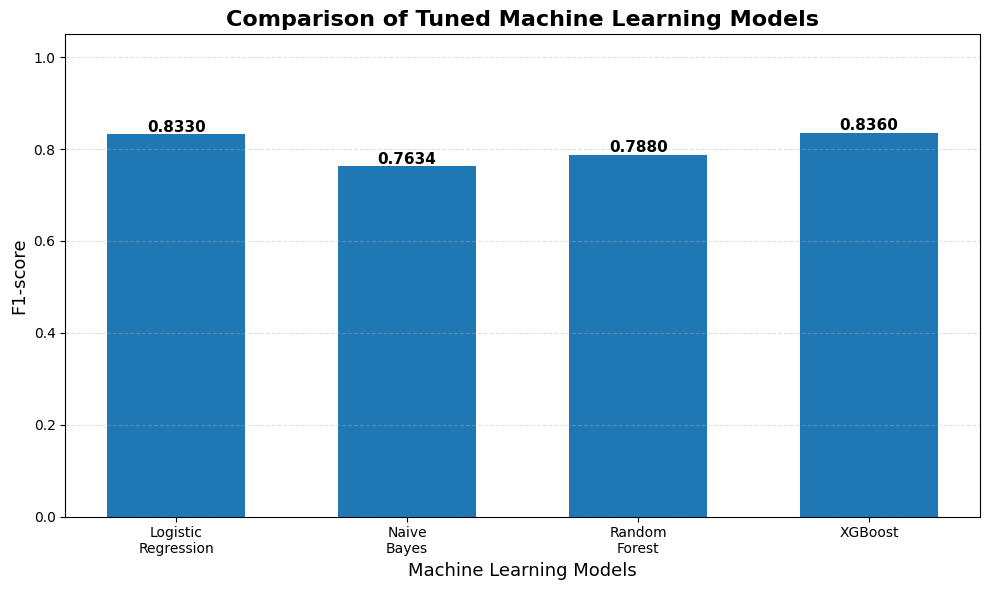

In [21]:
# I import the required libraries.
import matplotlib.pyplot as plt

# I define the model names.
models = [
    "Logistic\nRegression",
    "Naive\nBayes",
    "Random\nForest",
    "XGBoost"
]

# I store the F1-score of each tuned model.
f1_scores = [
    grid_lr_f1,
    grid_nb_f1,
    random_rf_f1,
    random_xgb_f1
]

# I create the bar chart.
plt.figure(figsize=(10,6))

bars = plt.bar(
    models,
    f1_scores,
    width=0.6
)

# I display the value above each bar.
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# I customize the graph.
plt.title(
    "Comparison of Tuned Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=13
)

plt.ylabel(
    "F1-score",
    fontsize=13
)

plt.ylim(0, 1.05)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Combined ROC-AUC Graph for all Tuned Models

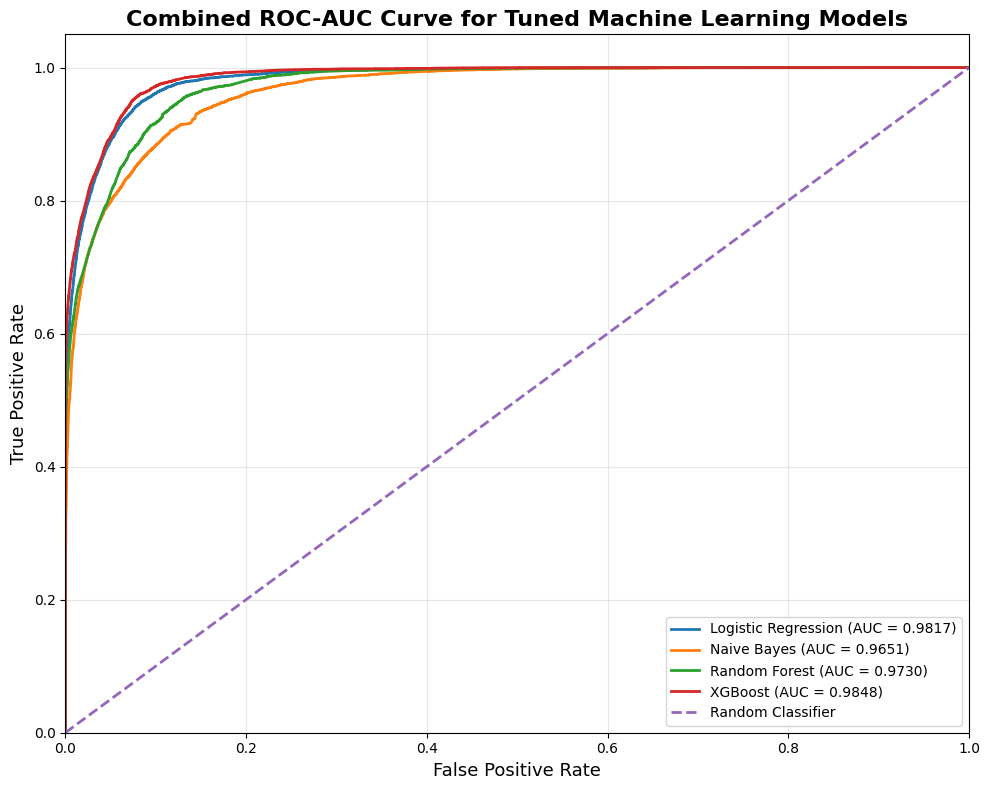

In [22]:
# I import the required libraries.
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

from sklearn.metrics import roc_curve, auc

# I convert the test labels into binary format.
y_test_bin = label_binarize(
    y_test,
    classes=range(len(label_encoder.classes_))
)

# I calculate the ROC curve for Logistic Regression.
fpr_lr, tpr_lr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_grid_lr.ravel()
)

roc_auc_lr = auc(
    fpr_lr,
    tpr_lr
)

# I calculate the ROC curve for Naive Bayes.
fpr_nb, tpr_nb, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_grid_nb.ravel()
)

roc_auc_nb = auc(
    fpr_nb,
    tpr_nb
)

# I calculate the ROC curve for Random Forest.
fpr_rf, tpr_rf, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_random_rf.ravel()
)

roc_auc_rf = auc(
    fpr_rf,
    tpr_rf
)

# I calculate the ROC curve for XGBoost.
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_random_xgb.ravel()
)

roc_auc_xgb = auc(
    fpr_xgb,
    tpr_xgb
)

# I create the ROC-AUC comparison graph.
plt.figure(figsize=(10,8))

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.4f})"
)

plt.plot(
    fpr_nb,
    tpr_nb,
    linewidth=2,
    label=f"Naive Bayes (AUC = {roc_auc_nb:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc_rf:.4f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost (AUC = {roc_auc_xgb:.4f})"
)

# I plot the random classifier line.
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

# I customize the graph.
plt.title(
    "Combined ROC-AUC Curve for Tuned Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13
)

plt.xlim([0,1])

plt.ylim([0,1.05])

plt.grid(alpha=0.3)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

plt.show()

# Combined Comparative Table for all Default and Tuned Models 

In [36]:
# I import the required libraries.
import pandas as pd
from IPython.display import display

# I create the comparison table.
df_all_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "XGBoost",
        "Logistic Regression (Tuned)",
        "Naive Bayes (Tuned)",
        "Random Forest (Tuned)",
        "XGBoost (Tuned)"
    ],

    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        rf_accuracy,
        xgb_accuracy,
        grid_lr_accuracy,
        grid_nb_accuracy,
        random_rf_accuracy,
        random_xgb_accuracy
    ],

    "Precision": [
        lr_precision,
        nb_precision,
        rf_precision,
        xgb_precision,
        grid_lr_precision,
        grid_nb_precision,
        random_rf_precision,
        random_xgb_precision
    ],

    "Recall": [
        lr_recall,
        nb_recall,
        rf_recall,
        xgb_recall,
        grid_lr_recall,
        grid_nb_recall,
        random_rf_recall,
        random_xgb_recall
    ],

    "F1-score": [
        lr_f1,
        nb_f1,
        rf_f1,
        xgb_f1,
        grid_lr_f1,
        grid_nb_f1,
        random_rf_f1,
        random_xgb_f1
    ],

    "ROC-AUC": [
        lr_roc_auc,
        nb_roc_auc,
        rf_roc_auc,
        xgb_roc_auc,
        grid_lr_roc_auc,
        grid_nb_roc_auc,
        random_rf_roc_auc,
        random_xgb_roc_auc
    ]

})

# I round all metric values.
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

df_all_results[metric_columns] = df_all_results[
    metric_columns
].round(4)

# I display the formatted table.
display(
    df_all_results.style
    .set_caption("Comparative Performance of Default and Tuned Machine Learning Models")
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt",
        "padding": "8px"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "15pt"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-size", "12pt"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])
)

# I print the comparison table.
print("\nComparative Performance of Default and Tuned Machine Learning Models\n")

print(df_all_results)

Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.833100,0.837600,0.833100,0.834600,0.968900
Naive Bayes,0.776600,0.766100,0.776600,0.763400,0.958000
Random Forest,0.822700,0.826800,0.822700,0.823500,0.961500
XGBoost,0.831200,0.850400,0.831200,0.829500,0.970200
Logistic Regression (Tuned),0.833100,0.835000,0.833100,0.833000,0.969500
Naive Bayes (Tuned),0.776600,0.766100,0.776600,0.763400,0.958000
Random Forest (Tuned),0.793200,0.806900,0.793200,0.788000,0.957000
XGBoost (Tuned),0.837100,0.849300,0.837100,0.836000,0.971800



Comparative Performance of Default and Tuned Machine Learning Models

                         Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0          Logistic Regression    0.8331     0.8376  0.8331    0.8346   0.9689
1                  Naive Bayes    0.7766     0.7661  0.7766    0.7634   0.9580
2                Random Forest    0.8227     0.8268  0.8227    0.8235   0.9615
3                      XGBoost    0.8312     0.8504  0.8312    0.8295   0.9702
4  Logistic Regression (Tuned)    0.8331     0.8350  0.8331    0.8330   0.9695
5          Naive Bayes (Tuned)    0.7766     0.7661  0.7766    0.7634   0.9580
6        Random Forest (Tuned)    0.7932     0.8069  0.7932    0.7880   0.9570
7              XGBoost (Tuned)    0.8371     0.8493  0.8371    0.8360   0.9718


# Combined Bar Graph for all Default and Tuned Models 

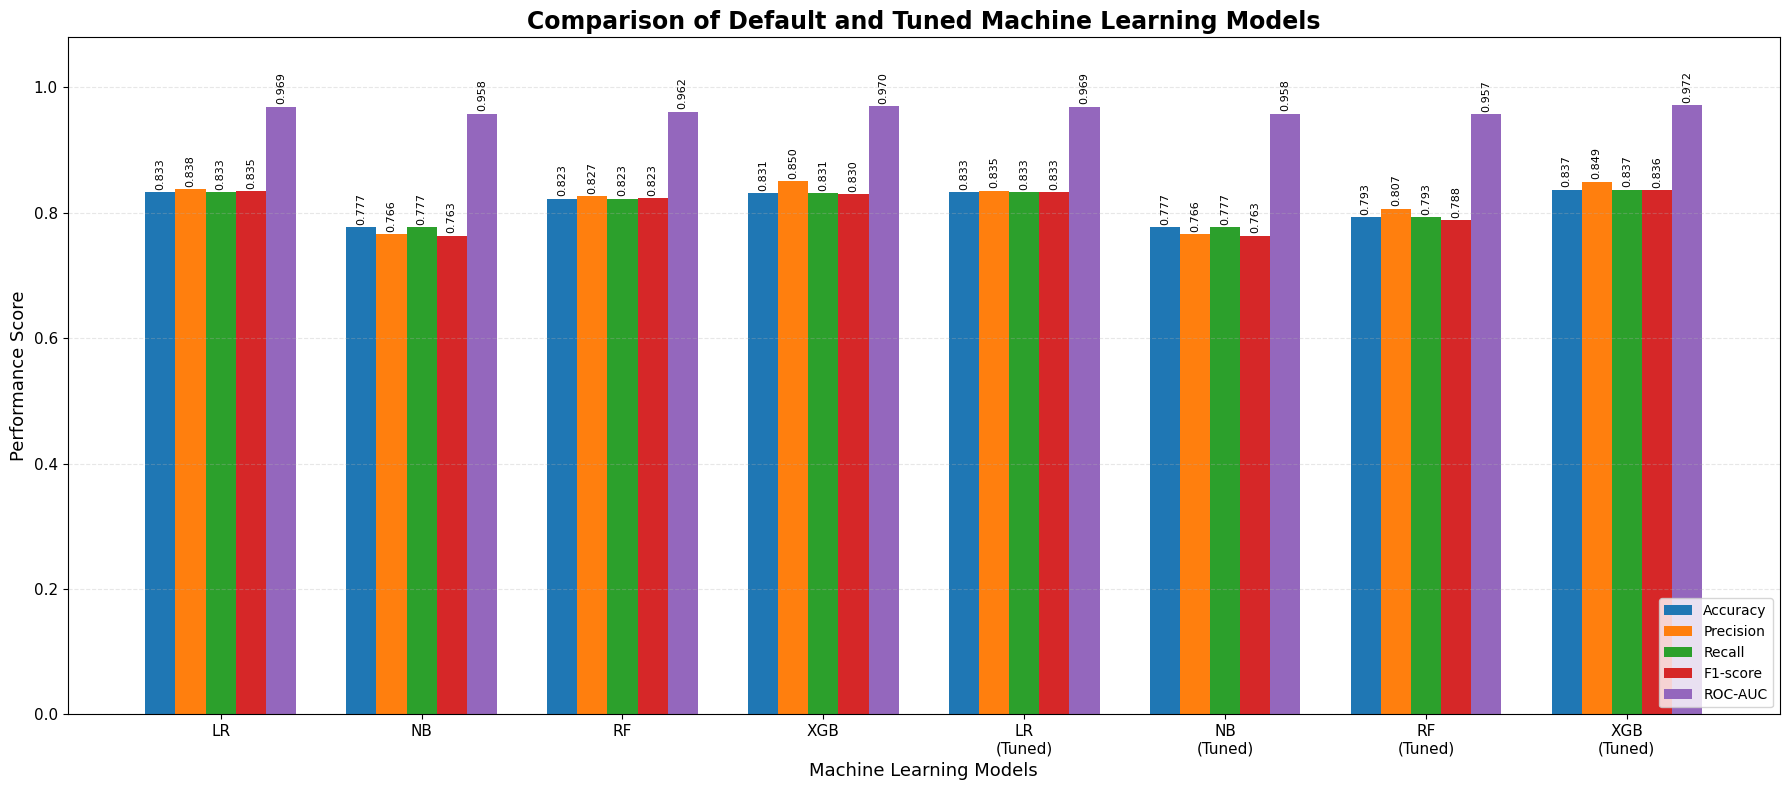

In [24]:
# I import the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I define the model names.
models = [
    "LR",
    "NB",
    "RF",
    "XGB",
    "LR\n(Tuned)",
    "NB\n(Tuned)",
    "RF\n(Tuned)",
    "XGB\n(Tuned)"
]

# I store the evaluation metrics.
accuracy = [
    lr_accuracy,
    nb_accuracy,
    rf_accuracy,
    xgb_accuracy,
    grid_lr_accuracy,
    grid_nb_accuracy,
    random_rf_accuracy,
    random_xgb_accuracy
]

precision = [
    lr_precision,
    nb_precision,
    rf_precision,
    xgb_precision,
    grid_lr_precision,
    grid_nb_precision,
    random_rf_precision,
    random_xgb_precision
]

recall = [
    lr_recall,
    nb_recall,
    rf_recall,
    xgb_recall,
    grid_lr_recall,
    grid_nb_recall,
    random_rf_recall,
    random_xgb_recall
]

f1 = [
    lr_f1,
    nb_f1,
    rf_f1,
    xgb_f1,
    grid_lr_f1,
    grid_nb_f1,
    random_rf_f1,
    random_xgb_f1
]

roc_auc = [
    lr_roc_auc,
    nb_roc_auc,
    rf_roc_auc,
    xgb_roc_auc,
    grid_lr_roc_auc,
    grid_nb_roc_auc,
    random_rf_roc_auc,
    random_xgb_roc_auc
]

# I create the grouped bar chart.
x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(18,8))

bars1 = plt.bar(x - 2*width, accuracy, width, label="Accuracy")
bars2 = plt.bar(x - width, precision, width, label="Precision")
bars3 = plt.bar(x, recall, width, label="Recall")
bars4 = plt.bar(x + width, f1, width, label="F1-score")
bars5 = plt.bar(x + 2*width, roc_auc, width, label="ROC-AUC")

# I display the values above each bar.
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

# I customize the graph.
plt.title(
    "Comparison of Default and Tuned Machine Learning Models",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=13
)

plt.ylabel(
    "Performance Score",
    fontsize=13
)

plt.xticks(
    x,
    models,
    fontsize=11
)

plt.yticks(fontsize=11)

plt.ylim(0, 1.08)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

plt.show()

# Overall Comparison Graph 

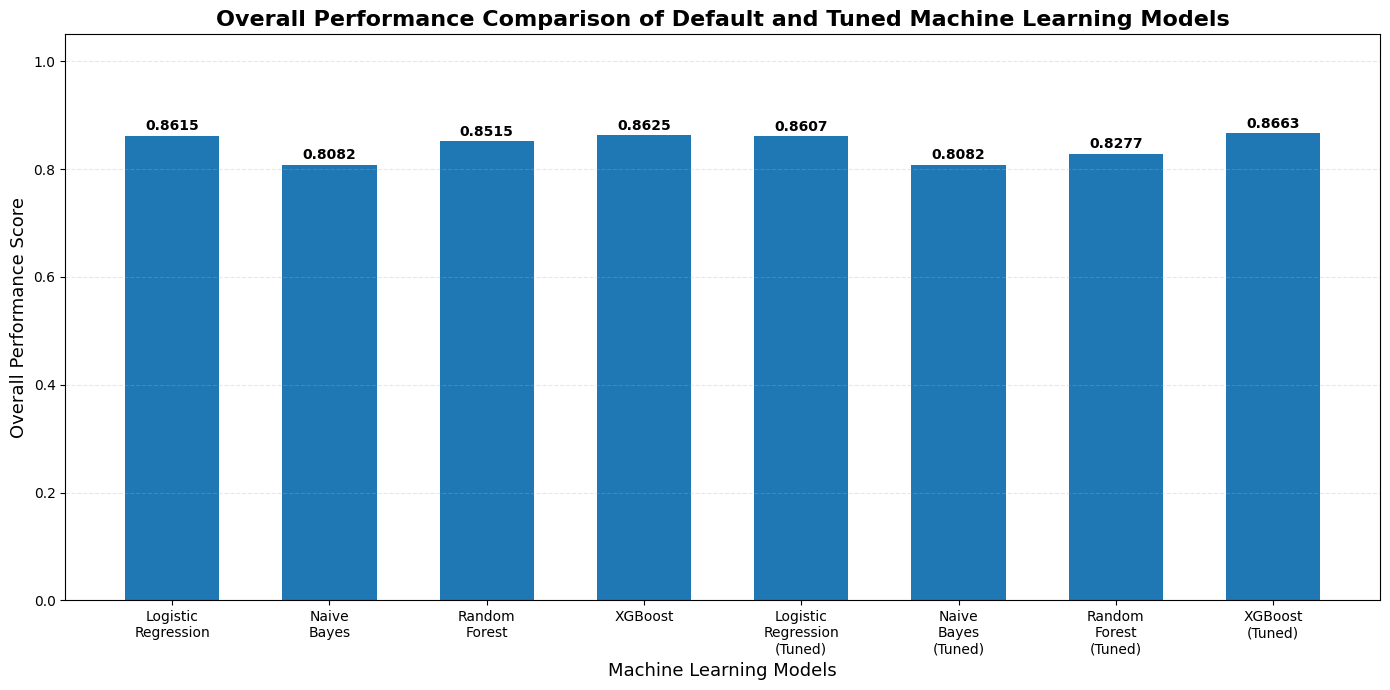

In [25]:
# I import the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I define the model names.
models = [
    "Logistic\nRegression",
    "Naive\nBayes",
    "Random\nForest",
    "XGBoost",
    "Logistic\nRegression\n(Tuned)",
    "Naive\nBayes\n(Tuned)",
    "Random\nForest\n(Tuned)",
    "XGBoost\n(Tuned)"
]

# I calculate the overall performance score for each model.
overall_scores = [

    (lr_accuracy + lr_precision + lr_recall + lr_f1 + lr_roc_auc) / 5,

    (nb_accuracy + nb_precision + nb_recall + nb_f1 + nb_roc_auc) / 5,

    (rf_accuracy + rf_precision + rf_recall + rf_f1 + rf_roc_auc) / 5,

    (xgb_accuracy + xgb_precision + xgb_recall + xgb_f1 + xgb_roc_auc) / 5,

    (grid_lr_accuracy + grid_lr_precision + grid_lr_recall + grid_lr_f1 + grid_lr_roc_auc) / 5,

    (grid_nb_accuracy + grid_nb_precision + grid_nb_recall + grid_nb_f1 + grid_nb_roc_auc) / 5,

    (random_rf_accuracy + random_rf_precision + random_rf_recall + random_rf_f1 + random_rf_roc_auc) / 5,

    (random_xgb_accuracy + random_xgb_precision + random_xgb_recall + random_xgb_f1 + random_xgb_roc_auc) / 5
]

# I create the figure.
plt.figure(figsize=(14,7))

bars = plt.bar(
    models,
    overall_scores,
    width=0.6
)

# I display the values above each bar.
for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# I customize the graph.
plt.title(
    "Overall Performance Comparison of Default and Tuned Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=13
)

plt.ylabel(
    "Overall Performance Score",
    fontsize=13
)

plt.ylim(0, 1.05)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(
    fontsize=10
)

plt.tight_layout()

plt.show()

# Best Performing Model

In [27]:
# I import the required libraries.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# I use the best-performing XGBoost model.
best_model = best_xgb_model

# I predict the class labels.
best_model_predictions = best_model.predict(
    X_test
)

# I predict the class probabilities.
best_model_probabilities = best_model.predict_proba(
    X_test
)

# I calculate the evaluation metrics.
best_accuracy = accuracy_score(
    y_test,
    best_model_predictions
)

best_precision = precision_score(
    y_test,
    best_model_predictions,
    average="weighted"
)

best_recall = recall_score(
    y_test,
    best_model_predictions,
    average="weighted"
)

best_f1 = f1_score(
    y_test,
    best_model_predictions,
    average="weighted"
)

best_roc_auc = roc_auc_score(
    y_test,
    best_model_probabilities,
    multi_class="ovr",
    average="weighted"
)

# I calculate the confusion matrix.
best_confusion_matrix = confusion_matrix(
    y_test,
    best_model_predictions
)

# I display the evaluation metrics.
print("Best Model Evaluation")


print("Model      : Tuned XGBoost")
print("Accuracy   :", round(best_accuracy, 4))
print("Precision  :", round(best_precision, 4))
print("Recall     :", round(best_recall, 4))
print("F1-score   :", round(best_f1, 4))
print("ROC-AUC    :", round(best_roc_auc, 4))

# I display the classification report.
print("\nClassification Report")

print(
    classification_report(
        y_test,
        best_model_predictions,
        target_names=label_encoder.classes_
    )
)

Best Model Evaluation
Model      : Tuned XGBoost
Accuracy   : 0.8371
Precision  : 0.8493
Recall     : 0.8371
F1-score   : 0.836
ROC-AUC    : 0.9718

Classification Report
                     precision    recall  f1-score   support

                age       0.98      0.97      0.98      1598
          ethnicity       0.99      0.98      0.98      1592
             gender       0.92      0.84      0.87      1590
  not_cyberbullying       0.66      0.46      0.54      1587
other_cyberbullying       0.57      0.83      0.68      1565
           religion       0.97      0.95      0.96      1600

           accuracy                           0.84      9532
          macro avg       0.85      0.84      0.84      9532
       weighted avg       0.85      0.84      0.84      9532



# Saving the Best Model

In [17]:
# I import joblib for saving the trained objects.
import joblib

# I save the best tuned XGBoost model.
joblib.dump(
    best_xgb_model,
    "cyber_xgb_model.pkl"
)

# I save the TF-IDF vectorizer.
joblib.dump(
    tfidf,
    "cyber_tfidf.pkl"
)

# I save the Label Encoder.
joblib.dump(
    label_encoder,
    "cyber_label_encoder.pkl"
)
print("cyber_xgb_model.pkl")
print("cyber_tfidf.pkl")
print("cyber_label_encoder.pkl")

cyber_xgb_model.pkl
cyber_tfidf.pkl
cyber_label_encoder.pkl


# SHAP Analysis Based on Best Model

SHAP Explainability Analysis

SHAP Summary Plot


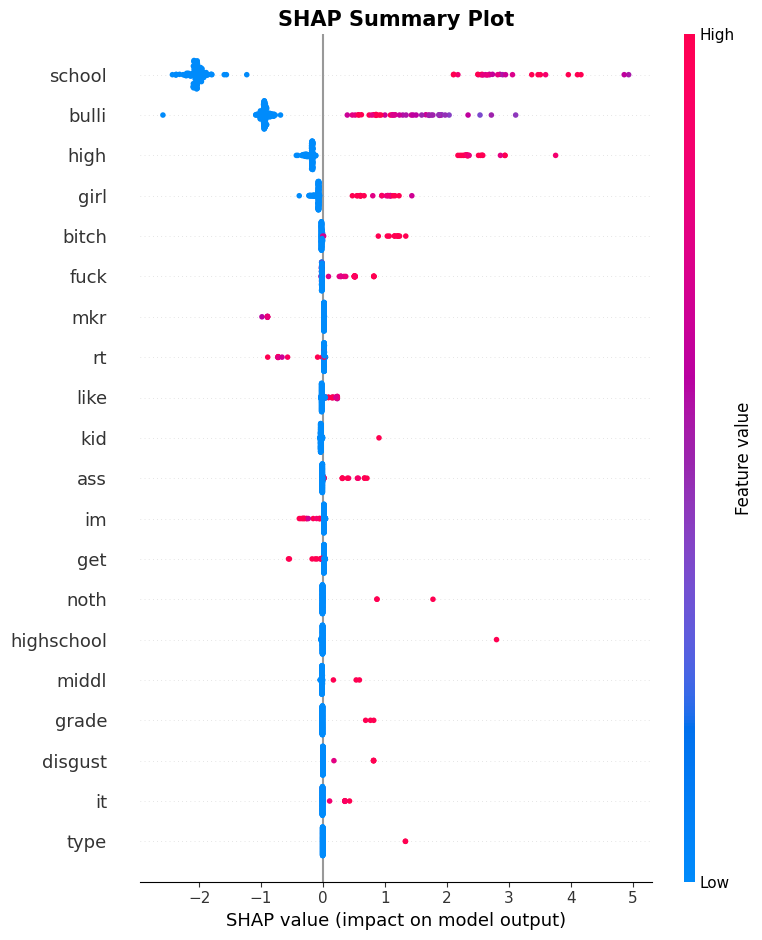


SHAP Feature Importance Plot


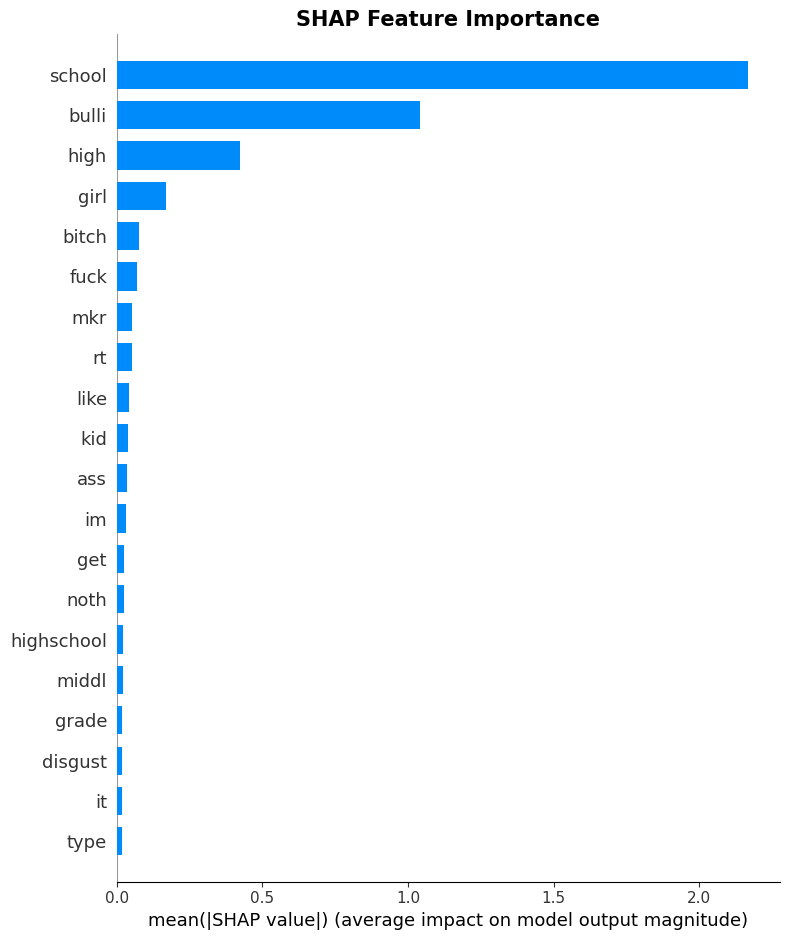


Top 20 Most Important Features
         Feature  Mean SHAP Value
3843      school         2.168207
606        bulli         1.041918
2036        high         0.422180
1817        girl         0.168039
461        bitch         0.076899
1730        fuck         0.070825
2866         mkr         0.052660
3756          rt         0.050804
2621        like         0.043055
2480         kid         0.037914
258          ass         0.033872
2194          im         0.031720
1799         get         0.024734
3058        noth         0.024449
2041  highschool         0.021615
2826       middl         0.021476
1871       grade         0.019253
1224     disgust         0.018930
2350          it         0.018286
4623        type         0.017376


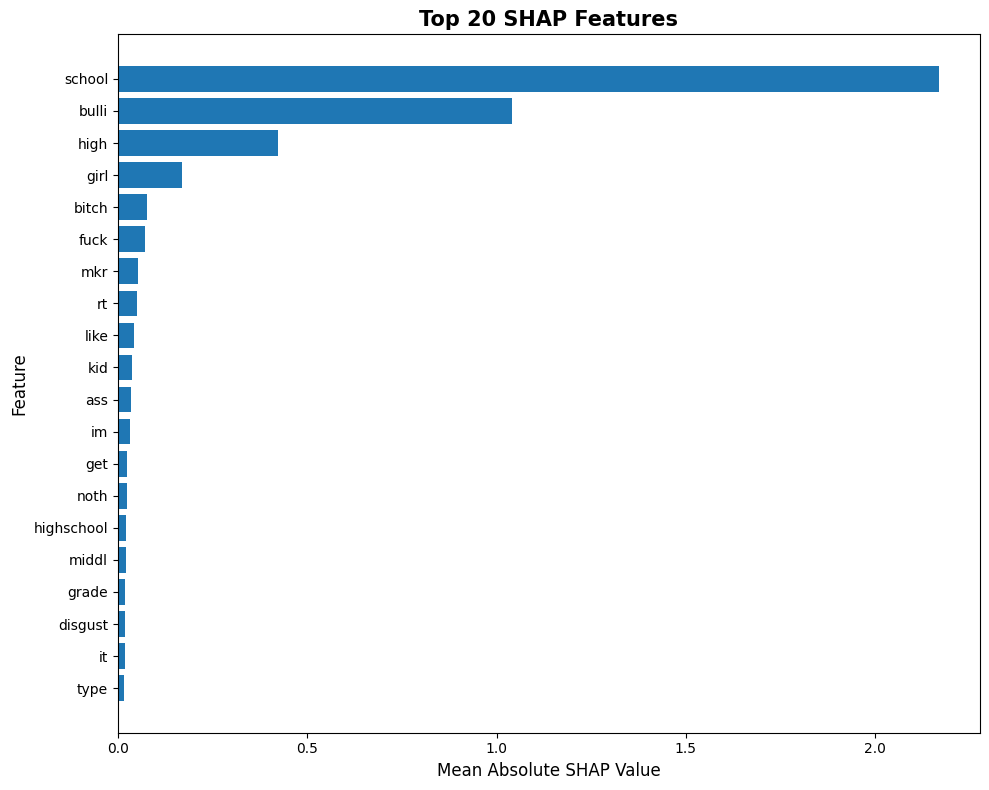


SHAP Dependence Plot


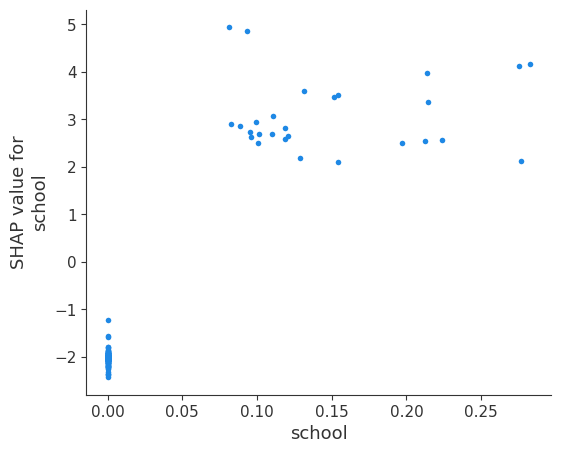

In [18]:
# I import the required libraries.
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# I initialize SHAP.
shap.initjs()

# I select a sample from the test dataset.
sample_size = 200

X_sample = X_test[:sample_size]

# I obtain the feature names from the TF-IDF vectorizer.
feature_names = tfidf.get_feature_names_out()

# I convert the sparse matrix into a DataFrame.
X_sample_df = pd.DataFrame(
    X_sample.toarray(),
    columns=feature_names
)

# I create the SHAP explainer.
explainer = shap.TreeExplainer(best_xgb_model)

# I calculate the SHAP values.
shap_values = explainer.shap_values(X_sample)

print("SHAP Explainability Analysis")

if isinstance(shap_values, list):

    summary_values = shap_values[0]

elif len(np.array(shap_values).shape) == 3:

    summary_values = shap_values[:, :, 0]

else:

    summary_values = shap_values

print("\nSHAP Summary Plot")

plt.figure(figsize=(12,8))

shap.summary_plot(
    summary_values,
    X_sample_df,
    show=False
)

plt.title(
    "SHAP Summary Plot",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

print("\nSHAP Feature Importance Plot")

plt.figure(figsize=(12,8))

shap.summary_plot(
    summary_values,
    X_sample_df,
    plot_type="bar",
    show=False
)

plt.title(
    "SHAP Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

mean_shap = np.abs(summary_values).mean(axis=0)

feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Mean SHAP Value": mean_shap

})

feature_importance = feature_importance.sort_values(

    by="Mean SHAP Value",

    ascending=False

)

print("\nTop 20 Most Important Features")

print(feature_importance.head(20))

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"][::-1],
    top20["Mean SHAP Value"][::-1]
)

plt.xlabel(
    "Mean Absolute SHAP Value",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    "Top 20 SHAP Features",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

print("\nSHAP Dependence Plot")

try:

    best_feature = feature_importance.iloc[0]["Feature"]

    shap.dependence_plot(
        best_feature,
        summary_values,
        X_sample_df,
        interaction_index=None
    )

except Exception as e:

    print("Dependence plot could not be generated.")

    print(e)

# Prototype for Human Evaluation : FeedBack Collection

In [ ]:
import tkinter as tk
from tkinter import messagebox
from tkinter import ttk
import joblib
import csv
import os
from datetime import datetime


# Load the saved model, TF-IDF vectorizer and label encoder.
try:

    best_xgb_model = joblib.load(
        "cyber_xgb_model.pkl"
    )

    tfidf = joblib.load(
        "cyber_tfidf.pkl"
    )

    label_encoder = joblib.load(
        "cyber_label_encoder.pkl"
    )

    print("Model loaded successfully.")
    print("Model classes:", best_xgb_model.classes_)
    print("Label Encoder classes:", label_encoder.classes_)

    if len(best_xgb_model.classes_) != len(label_encoder.classes_):

        raise ValueError(
            "The XGBoost model and Label Encoder "
            "have different numbers of classes."
        )

except Exception as e:

    messagebox.showerror(
        "Loading Error",
        "The required model files could not be loaded.\n\n"
        + str(e)
    )

    raise SystemExit


# Create the main application window.
window = tk.Tk()

window.title(
    "Cyberbullying Detection Prototype"
)

window.geometry(
    "1150x700"
)

window.configure(
    bg="#F4F6F8"
)

window.resizable(
    True,
    True
)


# Create the main heading.
heading = tk.Label(

    window,

    text="Cyberbullying Detection Prototype",

    font=("Arial", 22, "bold"),

    bg="#1F4E79",

    fg="white",

    pady=15

)

heading.pack(
    fill="x"
)


# Create a subtitle.
subtitle = tk.Label(

    window,

    text="Multi-Class Social Media Comment Classification",

    font=("Arial", 11),

    bg="#D9EAF7",

    fg="#1F2937",

    pady=8

)

subtitle.pack(
    fill="x"
)


# Create the main content area.
main_frame = tk.Frame(

    window,

    bg="#F4F6F8"

)

main_frame.pack(
    fill="both",
    expand=True,
    padx=20,
    pady=20
)


# Create the prediction panel on the left.
prediction_frame = tk.LabelFrame(

    main_frame,

    text="  Cyberbullying Prediction  ",

    font=("Arial", 14, "bold"),

    bg="white",

    fg="#1F4E79",

    bd=2,

    relief="groove",

    padx=15,

    pady=15

)

prediction_frame.pack(

    side="left",

    fill="both",

    expand=True,

    padx=(0, 10)

)


# Create the instruction.
instruction = tk.Label(

    prediction_frame,

    text="Enter a social media comment below:",

    font=("Arial", 12, "bold"),

    bg="white",

    fg="#333333"

)

instruction.pack(

    anchor="w",

    pady=(5, 8)

)


# Create a frame for the text box and scrollbar.
text_frame = tk.Frame(

    prediction_frame,

    bg="white"

)

text_frame.pack(

    fill="both",

    expand=False

)


# Create the comment text box.
text_box = tk.Text(

    text_frame,

    height=12,

    width=55,

    font=("Arial", 11),

    wrap=tk.WORD,

    bg="#FAFAFA",

    fg="#222222",

    insertbackground="#1F4E79",

    relief="solid",

    bd=1,

    padx=8,

    pady=8

)

text_box.pack(

    side="left",

    fill="both",

    expand=True

)


# Create the scrollbar for the comment box.
text_scrollbar = tk.Scrollbar(

    text_frame,

    orient="vertical",

    command=text_box.yview

)

text_scrollbar.pack(

    side="right",

    fill="y"

)


text_box.configure(

    yscrollcommand=text_scrollbar.set

)


# Store the current prediction.
current_prediction = tk.StringVar()

current_prediction.set("")


# Create the prediction result area.
result_frame = tk.Frame(

    prediction_frame,

    bg="#EAF2F8",

    bd=1,

    relief="solid"

)

result_frame.pack(

    fill="x",

    pady=18

)


result_label = tk.Label(

    result_frame,

    text="Prediction will appear here",

    font=("Arial", 16, "bold"),

    bg="#EAF2F8",

    fg="#1F4E79",

    pady=15

)

result_label.pack(
    fill="x"
)


# Create the prediction button.
predict_button = tk.Button(

    prediction_frame,

    text="Predict",

    font=("Arial", 12, "bold"),

    width=16,

    bg="#1F4E79",

    fg="white",

    activebackground="#163A5C",

    activeforeground="white",

    cursor="hand2",

    bd=0,

    padx=10,

    pady=8,

    command=lambda: predict_text()

)

predict_button.pack(
    pady=5
)


# Create the clear button.
clear_button = tk.Button(

    prediction_frame,

    text="Clear",

    font=("Arial", 11, "bold"),

    width=16,

    bg="#D9E2F3",

    fg="#1F2937",

    activebackground="#B4C7E7",

    cursor="hand2",

    bd=0,

    padx=10,

    pady=7,

    command=lambda: clear_text()

)

clear_button.pack(
    pady=5
)


# Create the human evaluation panel on the right.
evaluation_frame = tk.LabelFrame(

    main_frame,

    text="  Human Evaluation  ",

    font=("Arial", 14, "bold"),

    bg="white",

    fg="#548235",

    bd=2,

    relief="groove",

    padx=15,

    pady=15

)

evaluation_frame.pack(

    side="right",

    fill="both",

    expand=True,

    padx=(10, 0)

)


# Create evaluation instructions.
evaluation_instruction = tk.Label(

    evaluation_frame,

    text=(
        "Please rate the prototype from 1 to 5.\n"
        "1 = Very Poor    5 = Excellent"
    ),

    font=("Arial", 10),

    bg="white",

    fg="#444444",

    justify="left"

)

evaluation_instruction.pack(

    anchor="w",

    pady=(5, 15)

)


# Create rating variables.
rating1 = tk.StringVar(value="Select")
rating2 = tk.StringVar(value="Select")
rating3 = tk.StringVar(value="Select")
rating4 = tk.StringVar(value="Select")
rating5 = tk.StringVar(value="Select")


rating_values = [
    "Select",
    "1",
    "2",
    "3",
    "4",
    "5"
]


# Function for creating rating rows.
def create_rating_row(parent, text, variable):

    row = tk.Frame(

        parent,

        bg="white"

    )

    row.pack(

        fill="x",

        pady=6

    )

    label = tk.Label(

        row,

        text=text,

        font=("Arial", 10, "bold"),

        bg="white",

        fg="#333333",

        width=25,

        anchor="w"

    )

    label.pack(
        side="left"
    )

    dropdown = ttk.Combobox(

        row,

        textvariable=variable,

        values=rating_values,

        state="readonly",

        width=12

    )

    dropdown.pack(
        side="right"
    )

    dropdown.current(0)


# Create the five evaluation factors.
create_rating_row(
    evaluation_frame,
    "1. Ease of Use",
    rating1
)

create_rating_row(
    evaluation_frame,
    "2. Prediction Clarity",
    rating2
)

create_rating_row(
    evaluation_frame,
    "3. Prediction Relevance",
    rating3
)

create_rating_row(
    evaluation_frame,
    "4. Interface Design",
    rating4
)

create_rating_row(
    evaluation_frame,
    "5. Overall Satisfaction",
    rating5
)


# Create feedback heading.
feedback_label = tk.Label(

    evaluation_frame,

    text="Additional Feedback",

    font=("Arial", 11, "bold"),

    bg="white",

    fg="#548235"

)

feedback_label.pack(

    anchor="w",

    pady=(18, 6)

)


# Create feedback frame.
feedback_frame = tk.Frame(

    evaluation_frame,

    bg="white"

)

feedback_frame.pack(

    fill="both",

    expand=True

)


# Create feedback text box.
feedback_box = tk.Text(

    feedback_frame,

    height=8,

    width=45,

    font=("Arial", 10),

    wrap=tk.WORD,

    bg="#FAFAFA",

    fg="#222222",

    insertbackground="#548235",

    relief="solid",

    bd=1,

    padx=8,

    pady=8

)

feedback_box.pack(

    side="left",

    fill="both",

    expand=True

)


# Create scrollbar for feedback.
feedback_scrollbar = tk.Scrollbar(

    feedback_frame,

    orient="vertical",

    command=feedback_box.yview

)

feedback_scrollbar.pack(

    side="right",

    fill="y"

)


feedback_box.configure(

    yscrollcommand=feedback_scrollbar.set

)


# Create the submit evaluation button.
submit_button = tk.Button(

    evaluation_frame,

    text="Submit Evaluation",

    font=("Arial", 12, "bold"),

    bg="#548235",

    fg="white",

    activebackground="#3F6228",

    activeforeground="white",

    cursor="hand2",

    bd=0,

    padx=15,

    pady=9,

    command=lambda: submit_evaluation()

)

submit_button.pack(

    pady=15

)


# Create the prediction function.
def predict_text():

    try:

        user_text = text_box.get(
            "1.0",
            tk.END
        ).strip()

        if len(user_text) == 0:

            messagebox.showwarning(

                "Input Required",

                "Please enter a social media comment."

            )

            return


        transformed_text = tfidf.transform(
            [user_text]
        )


        prediction = best_xgb_model.predict(
            transformed_text
        )


        predicted_id = int(
            prediction[0]
        )


        if predicted_id < 0 or predicted_id >= len(
            label_encoder.classes_
        ):

            raise ValueError(
                "Invalid predicted class."
            )


        predicted_class = label_encoder.inverse_transform(
            [predicted_id]
        )[0]


        current_prediction.set(
            str(predicted_class)
        )


        result_label.config(

            text=(
                "Predicted Class: "
                + str(predicted_class)
            ),

            fg="#1F4E79",

            bg="#EAF2F8"

        )


        
        print("PREDICTION RESULT")
        print("Input:", user_text)
        print("Predicted Class ID:", predicted_id)
        print("Predicted Class:", predicted_class)


    except Exception as e:

        messagebox.showerror(

            "Prediction Error",

            "An error occurred while making "
            "the prediction:\n\n"
            + str(e)

        )


# Create the clear function.
def clear_text():

    text_box.delete(
        "1.0",
        tk.END
    )

    result_label.config(

        text="Prediction will appear here",

        fg="#1F4E79",

        bg="#EAF2F8"

    )

    current_prediction.set("")

    rating1.set("Select")
    rating2.set("Select")
    rating3.set("Select")
    rating4.set("Select")
    rating5.set("Select")

    feedback_box.delete(
        "1.0",
        tk.END
    )


# Create the human evaluation submission function.
def submit_evaluation():

    try:

        if current_prediction.get() == "":

            messagebox.showwarning(

                "Prediction Required",

                "Please enter a comment and generate "
                "a prediction before submitting the evaluation."

            )

            return


        ratings = [

            rating1.get(),
            rating2.get(),
            rating3.get(),
            rating4.get(),
            rating5.get()

        ]


        if "Select" in ratings:

            messagebox.showwarning(

                "Ratings Required",

                "Please provide a rating from 1 to 5 "
                "for all five evaluation factors."

            )

            return


        feedback = feedback_box.get(

            "1.0",

            tk.END

        ).strip()


        if len(feedback) == 0:

            messagebox.showwarning(

                "Feedback Required",

                "Please provide written feedback "
                "before submitting the evaluation."

            )

            return


        timestamp = datetime.now().strftime(

            "%Y-%m-%d %H:%M:%S"

        )


        filename = (
            "cyber_human_evaluation.csv"
        )


        file_exists = os.path.isfile(
            filename
        )


        with open(

            filename,

            "a",

            newline="",

            encoding="utf-8"

        ) as file:

            writer = csv.writer(
                file
            )


            if not file_exists:

                writer.writerow([

                    "Timestamp",

                    "Predicted Class",

                    "Ease of Use",

                    "Prediction Clarity",

                    "Prediction Relevance",

                    "Interface Design",

                    "Overall Satisfaction",

                    "Feedback"

                ])


            writer.writerow([

                timestamp,

                current_prediction.get(),

                rating1.get(),

                rating2.get(),

                rating3.get(),

                rating4.get(),

                rating5.get(),

                feedback

            ])


        messagebox.showinfo(

            "Evaluation Submitted",

            "Thank you. Your ratings and feedback "
            "have been recorded successfully."

        )


        rating1.set("Select")
        rating2.set("Select")
        rating3.set("Select")
        rating4.set("Select")
        rating5.set("Select")

        feedback_box.delete(
            "1.0",
            tk.END
        )


    except Exception as e:

        messagebox.showerror(

            "Evaluation Error",

            "The evaluation could not be saved:\n\n"
            + str(e)

        )


# Start the application.
window.mainloop()